# EDA — Ipi

---
## 0. Configuración del Dataset

In [1]:
# ============================================================
# CONFIGURACIÓN: IPI
# ============================================================

DATASET_CONFIG = {
    'nombre': 'ipi',
    'archivo': 'ipi_constantes_2025_1975_2026.csv',
'frecuencia_original': 'mensual',
    'col_fecha': 'fecha',
    'variable_principal': 'ipi_constantes_2025_total_industria',
    'variables_desgloses': [
        'ipi_constantes_2025_energia',
        'ipi_constantes_2025_bienes_equipo',
        'ipi_constantes_2025_bienes_intermedios',
        'ipi_constantes_2025_bienes_consumo',
    ],
    'columnas_numericas': [
        'ipi_constantes_2025_total_industria',
        'ipi_constantes_2025_energia',
        'ipi_constantes_2025_bienes_equipo',
        'ipi_constantes_2025_bienes_intermedios',
        'ipi_constantes_2025_bienes_consumo',
    ],
    'unidades': 'índice (base 2025=100)',
    'notas': 'INE. Índice de Producción Industrial en términos constantes 2025. Mensual desde 1975.',
}

VAR_PRINCIPAL = DATASET_CONFIG['variable_principal']
NOMBRE        = DATASET_CONFIG['nombre']
UNIDADES      = DATASET_CONFIG['unidades']

PERIODO_ESTACIONAL = {
    'trimestral': 4,
    'mensual': 12,
    'diaria': 365,
}[DATASET_CONFIG['frecuencia_original']]

LAGS_ACF = {
    'trimestral': 16,
    'mensual': 36,
    'diaria': 60,
}[DATASET_CONFIG['frecuencia_original']]

print(f'Dataset configurado: {NOMBRE}')
print(f'Variable principal:  {VAR_PRINCIPAL}')
print(f'Frecuencia:          {DATASET_CONFIG["frecuencia_original"]}')
print(f'Periodo estacional:  {PERIODO_ESTACIONAL}')

Dataset configurado: ipi
Variable principal:  ipi_constantes_2025_total_industria
Frecuencia:          mensual
Periodo estacional:  12


---
## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import warnings
from pathlib import Path
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

RUTA_BASE = Path(r'C:\Users\marco\PycharmProjects\TFM_Marcos\Datasets')

COLOR_PRINCIPAL = '#5E35B1'
COLORES_DESGLOSES = ['#00897B', '#FF7043', '#FFC107', '#1565C0', '#AD1457']

EVENTOS = {
    '1986-01-01': 'Entrada UE',
    '1999-01-01': 'Euro',
    '2008-09-01': 'Crisis\nfinanciera',
    '2012-01-01': 'Crisis\ndeuda',
    '2020-03-01': 'COVID-19',
}

---
## 1. Carga y Diagnóstico Básico

In [3]:
ruta = RUTA_BASE / DATASET_CONFIG['archivo']
df = pd.read_csv(ruta)
df[DATASET_CONFIG['col_fecha']] = pd.to_datetime(df[DATASET_CONFIG['col_fecha']])
df = df.set_index(DATASET_CONFIG['col_fecha']).sort_index()

for col in DATASET_CONFIG['columnas_numericas']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset: {NOMBRE}')
print(f'Notas:   {DATASET_CONFIG["notas"]}')
print('=' * 60)
print(f'Shape:          {df.shape}')
print(f'Rango temporal: {df.index.min().date()} a {df.index.max().date()}')
print(f'Observaciones:  {len(df)}')
print(f'Columnas:       {list(df.columns)}')

Dataset: ipi
Notas:   INE. Índice de Producción Industrial en términos constantes 2025. Mensual desde 1975.
Shape:          (610, 9)
Rango temporal: 1975-01-01 a 2025-10-01
Observaciones:  610
Columnas:       ['año', 'mes', 'trimestre', 'periodo', 'ipi_constantes_2025_total_industria', 'ipi_constantes_2025_energia', 'ipi_constantes_2025_bienes_equipo', 'ipi_constantes_2025_bienes_intermedios', 'ipi_constantes_2025_bienes_consumo']


In [4]:
print('Primeras 3 filas:')
display(df.head(3))
print('\nÚltimas 3 filas:')
display(df.tail(3))

Primeras 3 filas:


,año,mes,trimestre,periodo,ipi_constantes_2025_total_industria,ipi_constantes_2025_energia,ipi_constantes_2025_bienes_equipo,ipi_constantes_2025_bienes_intermedios,ipi_constantes_2025_bienes_consumo
fecha,,,,,,,,,
1975-01-01,1975,1,1,1975T1,86.052,142.070,112.419,98.776,111.398
1975-02-01,1975,2,1,1975T1,87.905,62.822,144.442,67.244,63.804
1975-03-01,1975,3,1,1975T1,92.231,62.364,187.614,66.498,63.247



Últimas 3 filas:


,año,mes,trimestre,periodo,ipi_constantes_2025_total_industria,ipi_constantes_2025_energia,ipi_constantes_2025_bienes_equipo,ipi_constantes_2025_bienes_intermedios,ipi_constantes_2025_bienes_consumo
fecha,,,,,,,,,
2025-08-01,2025,8,3,2025T3,98.634,142.863,74.795,76.132,103.799
2025-09-01,2025,9,3,2025T3,134.790,135.478,133.971,114.203,138.452
2025-10-01,2025,10,4,2025T4,140.632,135.490,142.907,120.515,143.582


In [5]:
cols_num = DATASET_CONFIG['columnas_numericas']
cols_num = [c for c in cols_num if c in df.columns]

nulos = pd.DataFrame({
    'n_nulos': df[cols_num].isnull().sum(),
    'pct_nulos': df[cols_num].isnull().mean() * 100,
    'primer_valido': [df[c].first_valid_index() for c in cols_num],
    'ultimo_valido': [df[c].last_valid_index() for c in cols_num],
}).round(2)

print('Diagnóstico de valores faltantes:')
display(nulos)

n_dupl = df.index.duplicated().sum()
print(f'\nDuplicados de fecha: {n_dupl}')

Diagnóstico de valores faltantes:


,n_nulos,pct_nulos,primer_valido,ultimo_valido
ipi_constantes_2025_total_industria,0,0.000,1975-01-01,2025-10-01
ipi_constantes_2025_energia,0,0.000,1975-01-01,2025-10-01
ipi_constantes_2025_bienes_equipo,0,0.000,1975-01-01,2025-10-01
ipi_constantes_2025_bienes_intermedios,0,0.000,1975-01-01,2025-10-01
ipi_constantes_2025_bienes_consumo,0,0.000,1975-01-01,2025-10-01



Duplicados de fecha: 0


In [6]:
if len(df) > 1:
    diffs = df.index.to_series().diff().dropna()
    print(f'Intervalo mediano entre observaciones: {diffs.median()}')
    print(f'Intervalo mínimo:                      {diffs.min()}')
    print(f'Intervalo máximo:                      {diffs.max()}')

    umbral = diffs.median() * 2
    huecos = diffs[diffs > umbral]
    if len(huecos) > 0:
        print(f'\nHuecos temporales detectados ({len(huecos)}):')
        print(huecos)

Intervalo mediano entre observaciones: 31 days 00:00:00
Intervalo mínimo:                      28 days 00:00:00
Intervalo máximo:                      31 days 00:00:00


---
## 2. Series Temporales

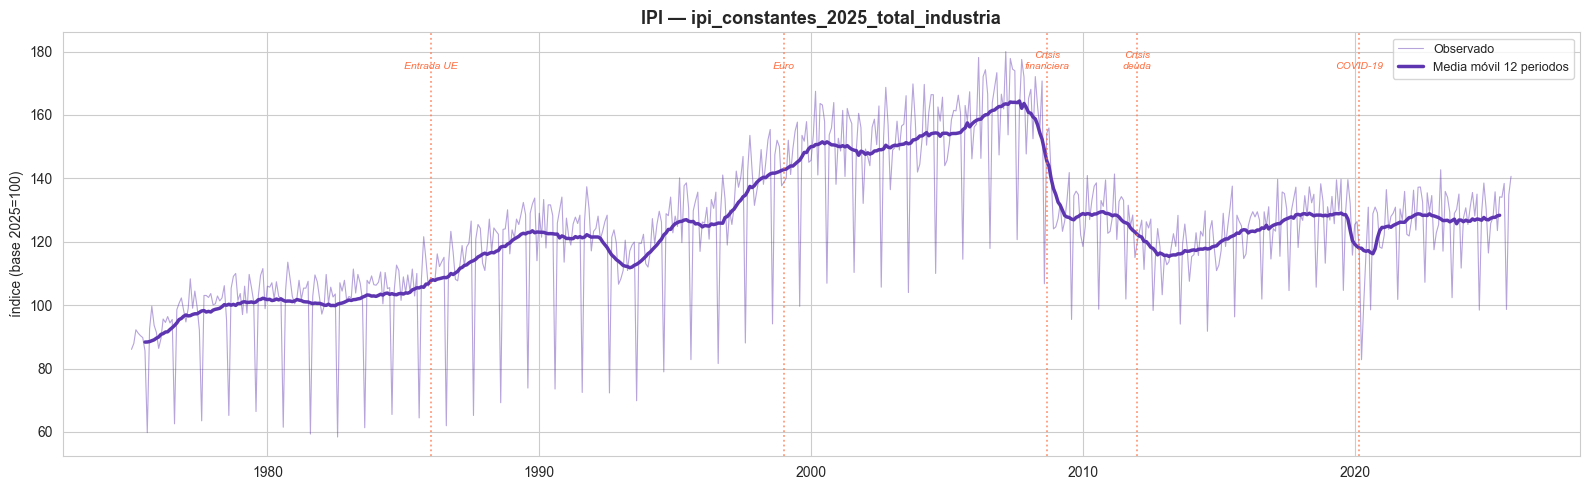

Mín: 58.40  (1982-08-01)
Máx: 179.98  (2007-03-01)


In [7]:
ventana_mm = PERIODO_ESTACIONAL

fig, ax = plt.subplots(figsize=(16, 5))

y = df[VAR_PRINCIPAL].dropna()
mm = y.rolling(ventana_mm, center=True).mean()

ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=0.8, alpha=0.45, label='Observado')
ax.plot(y.index, mm, color=COLOR_PRINCIPAL, lw=2.5,
        label=f'Media móvil {ventana_mm} periodos')

y_max = y.max()
for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if y.index.min() <= fecha_ev <= y.index.max():
        ax.axvline(fecha_ev, color='#FF7043', linestyle=':', lw=1.3, alpha=0.7)
        ax.text(fecha_ev, y_max * 0.97, texto,
                ha='center', fontsize=7.5, color='#FF7043', fontstyle='italic')

ax.set_title(f'{NOMBRE.upper()} — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')
ax.set_ylabel(UNIDADES, fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mín: {y.min():.2f}  ({y.idxmin().date()})')
print(f'Máx: {y.max():.2f}  ({y.idxmax().date()})')

### Análisis:

El `ipi_constantes_2025_total_industria` (Índice de Producción Industrial en volumen, base 2025) describe la trayectoria de la actividad industrial española con una marcada estructura cíclica y estacional, recorriendo desde un mínimo de 58,40 en agosto de 1982 hasta un máximo histórico de 179,98 en marzo de 2007. La serie observada presenta un patrón en dientes de sierra muy pronunciado, reflejo de la fuerte estacionalidad del verano industrial, sobre el que la media móvil de doce periodos revela la dinámica de fondo.

La tendencia describe tres grandes fases. Un crecimiento moderado entre 1975 y 1985 interrumpido por la reconversión industrial, una expansión sostenida desde la entrada en la CEE de 1986 hasta el pico previo a la crisis en 2007 (con la producción multiplicándose por aproximadamente 1,8 respecto a 1975), y un colapso entre 2008 y 2013 que devuelve el índice a niveles de mediados de los 90, en torno a 120, del que solo se recupera parcialmente. A diferencia del PIB, que sí recupera y supera su máximo pre-crisis, la producción industrial no vuelve a los niveles de 2007, lo que cuantifica la pérdida estructural de peso de la industria en la economía española. El confinamiento de 2020 produce un desplome puntual seguido de una recuperación rápida.

Para la predicción del paro, el IPI es uno de los indicadores con mayor fundamentación: la producción industrial es procíclica y su contracción precede o acompaña a la destrucción de empleo, especialmente en los episodios de crisis industrial. El análisis de la sección 9 cuantifica esta relación sobre la forma estacionaria.

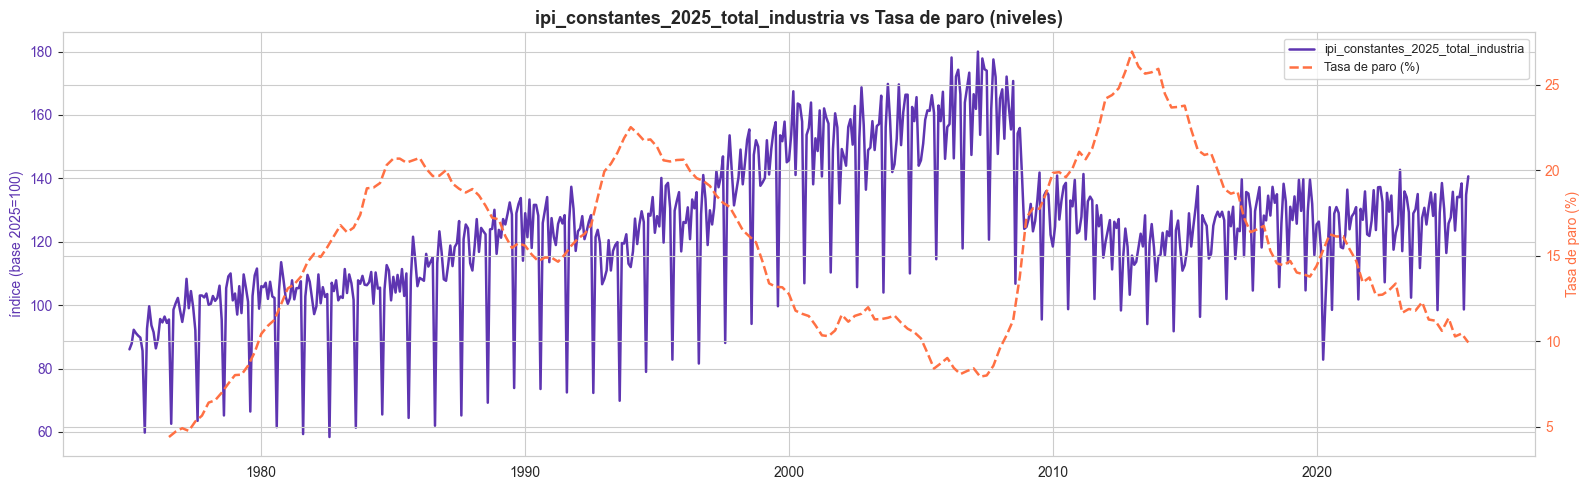

In [8]:
# Comparación de niveles con la tasa de paro (antes de analizar estacionariedad)
ruta_paro_s2 = RUTA_BASE / 'parados_sexo_edad.csv'
df_paro_s2 = pd.read_csv(ruta_paro_s2)
df_paro_s2['fecha'] = pd.to_datetime(df_paro_s2['fecha'])
df_paro_s2 = df_paro_s2.set_index('fecha').sort_index()
tasa_paro_s2 = pd.to_numeric(df_paro_s2['tasa_paro_ambos_sexos_total'], errors='coerce').dropna()

y = df[VAR_PRINCIPAL].dropna()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
ax1.plot(y.index, y, color=COLOR_PRINCIPAL, lw=1.8, label=VAR_PRINCIPAL)
ax2.plot(tasa_paro_s2.index, tasa_paro_s2, color='#FF7043', lw=1.8, linestyle='--', label='Tasa de paro (%)')
ax1.set_ylabel(UNIDADES, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')
ax1.set_title(f'{VAR_PRINCIPAL} vs Tasa de paro (niveles)', fontsize=13, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc='best')
plt.tight_layout()
plt.show()


### Análisis:

La relación en niveles entre el `ipi_constantes_2025_total_industria` y la tasa de paro es predominantemente inversa, coherente con el carácter procíclico de la producción industrial, aunque condicionada por la tendencia. Entre 1975 y 1985 ambos suben (el IPI crece de forma moderada y el paro escala del 5% al 21%), un tramo en que la reconversión industrial deteriora el empleo pese al crecimiento de la producción. Entre 1994 y 2007 la relación inversa se manifiesta con nitidez: el IPI se expande con fuerza hasta su máximo de 180 mientras el paro retrocede del 24% al 8%, la expresión del boom industrial generador de empleo. El tramo 2008-2013 es el más elocuente: el colapso de la producción industrial coincide exactamente con la escalada del paro hasta el 27%, el mayor deterioro del mercado laboral de la muestra. Desde 2014 el IPI se estabiliza en una meseta inferior a su máximo mientras el paro desciende hasta el 10%. El co-movimiento inverso es visible pero está dominado por la deriva de medio plazo de ambas series; la correlación en niveles resultaría espuria por la tendencia compartida, por lo que el análisis cuantitativo de la sección 9 se realiza sobre la variación interanual de la producción.

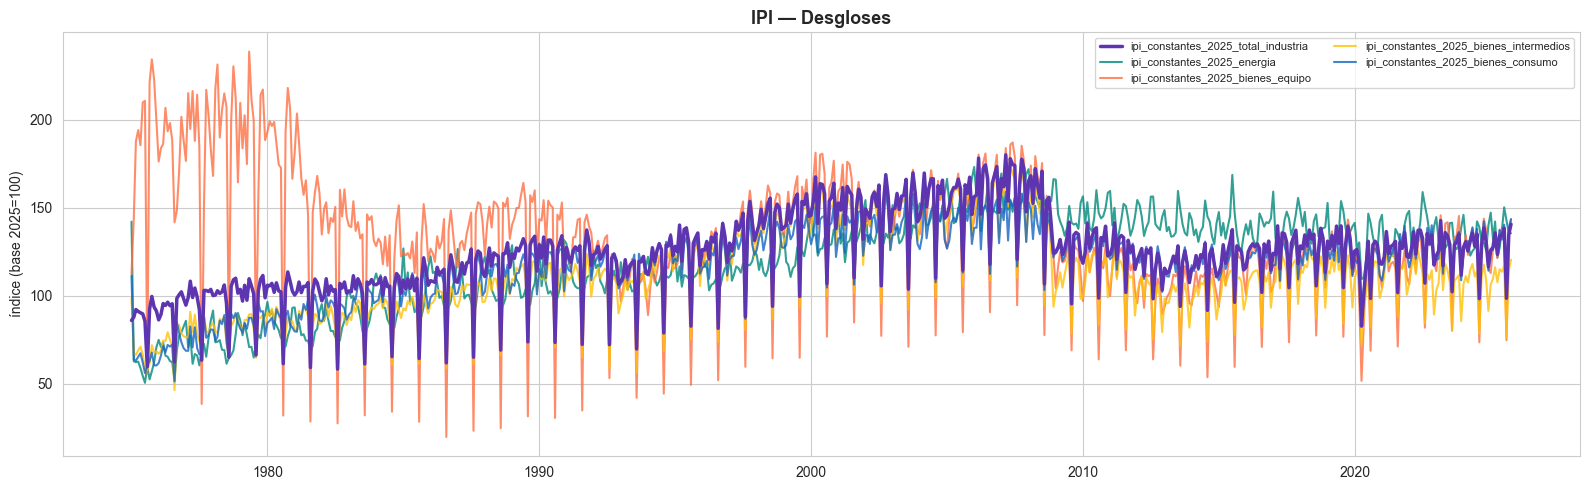

In [9]:
desgloses = [c for c in DATASET_CONFIG.get('variables_desgloses', []) if c in df.columns]

if desgloses:
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=2.5, label=VAR_PRINCIPAL, zorder=5)

    for col, color in zip(desgloses, COLORES_DESGLOSES):
        serie = df[col].dropna()
        ax.plot(serie.index, serie, color=color, lw=1.5, alpha=0.8, label=col)

    ax.set_title(f'{NOMBRE.upper()} — Desgloses', fontsize=13, fontweight='bold')
    ax.set_ylabel(UNIDADES, fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

### Análisis:

El desglose por destino económico muestra que los cuatro grandes componentes de la producción industrial comparten la estacionalidad estival y el colapso de 2008-2013, pero con amplitudes muy distintas. El componente de `bienes_equipo` es el más volátil de todos, con oscilaciones de gran amplitud que reflejan la sensibilidad de la inversión en bienes de capital al ciclo económico. La `energia` describe una trayectoria más sostenida y de fuerte crecimiento de largo plazo, mientras los `bienes_intermedios` y `bienes_consumo` siguen el perfil cíclico del agregado con menor amplitud.

Todos los componentes acusan con claridad las recesiones documentadas en la serie principal, en particular la contracción de 2008-2013, que afecta de forma generalizada a la producción industrial. La estacionalidad de agosto, visible como caídas regulares en todas las series, es común a todos los destinos económicos y responde al cierre estival generalizado de la actividad fabril española.

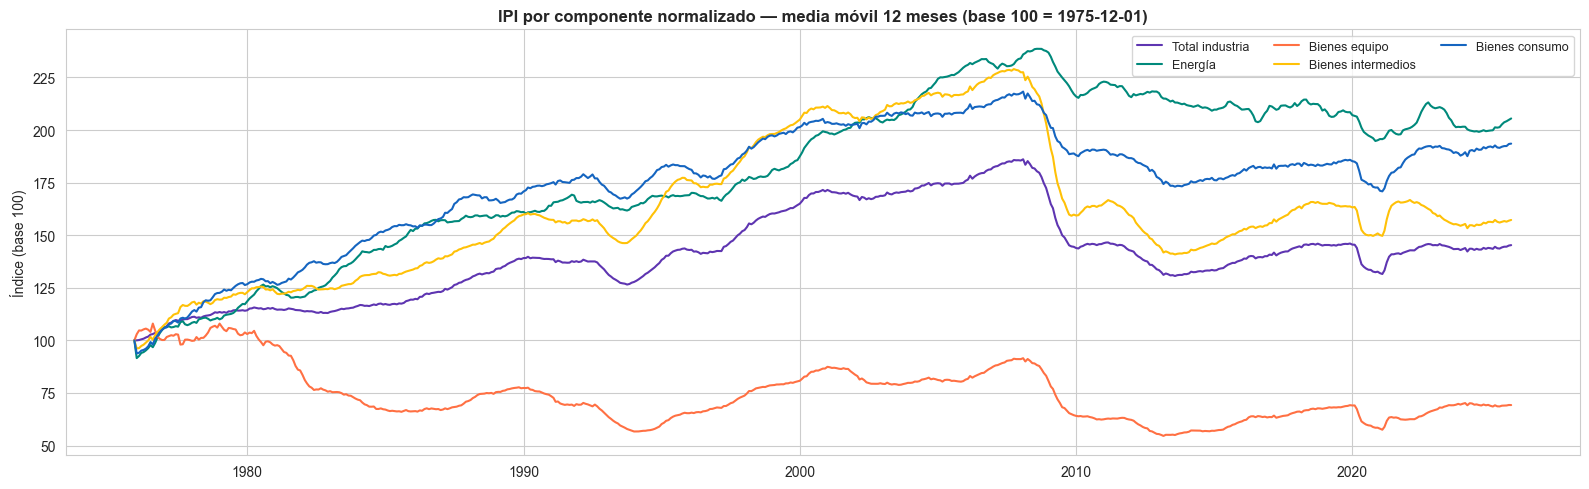

In [10]:
# Componentes del IPI normalizados a base 100
componentes_ipi = {
    'Total industria': 'ipi_constantes_2025_total_industria',
    'Energía': 'ipi_constantes_2025_energia',
    'Bienes equipo': 'ipi_constantes_2025_bienes_equipo',
    'Bienes intermedios': 'ipi_constantes_2025_bienes_intermedios',
    'Bienes consumo': 'ipi_constantes_2025_bienes_consumo',
}
cols_ipi = {k: v for k, v in componentes_ipi.items() if v in df.columns}

if cols_ipi:
    df_ipi_raw = df[list(cols_ipi.values())].dropna()
    df_ipi_norm = df_ipi_raw.rolling(12).mean().dropna()
    df_ipi_norm = df_ipi_norm / df_ipi_norm.iloc[0] * 100
    df_ipi_norm.columns = list(cols_ipi.keys())

    fig, ax = plt.subplots(figsize=(16, 5))
    for col, color in zip(df_ipi_norm.columns, [COLOR_PRINCIPAL] + COLORES_DESGLOSES):
        ax.plot(df_ipi_norm.index, df_ipi_norm[col], lw=1.5, label=col, color=color)

    ax.set_title(f'IPI por componente normalizado — media móvil 12 meses (base 100 = {df_ipi_norm.index[0].date()})',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Índice (base 100)', fontsize=10)
    ax.legend(fontsize=9, ncol=3)
    plt.tight_layout()
    plt.show()

### Análisis:

La representación de los componentes normalizados a base 100 en 1975, suavizados con media móvil de doce meses, revela una recomposición estructural profunda de la industria española a lo largo de cinco décadas. La divergencia más llamativa es la del componente de `bienes_equipo`, que tras un breve repunte inicial se desploma hasta valores en torno a 55-70 y permanece por debajo de su nivel de partida durante toda la muestra: la producción española de bienes de capital es hoy inferior a la de 1975, reflejo de la deindustrialización y la externalización de la manufactura de equipo hacia economías con menores costes.

En el extremo opuesto, la `energia` es el componente más expansivo, multiplicando su nivel por aproximadamente 2,4 hasta el pico de 2008, seguida de los `bienes_consumo` y los `bienes_intermedios`, que crecen de forma sostenida hasta 2007. El `total_industria` se sitúa en una posición intermedia, multiplicando su producción por aproximadamente 1,85 en el pico. La crisis de 2008-2013 produce una caída generalizada, más severa en los bienes intermedios, y la recuperación posterior es parcial y desigual: solo la energía se aproxima a sus máximos previos. Esta heterogeneidad confirma que el agregado industrial esconde dinámicas sectoriales muy distintas, con la inversión en equipo en declive estructural y la energía y el consumo como sostén del índice.

---
## 3. Distribución y Outliers

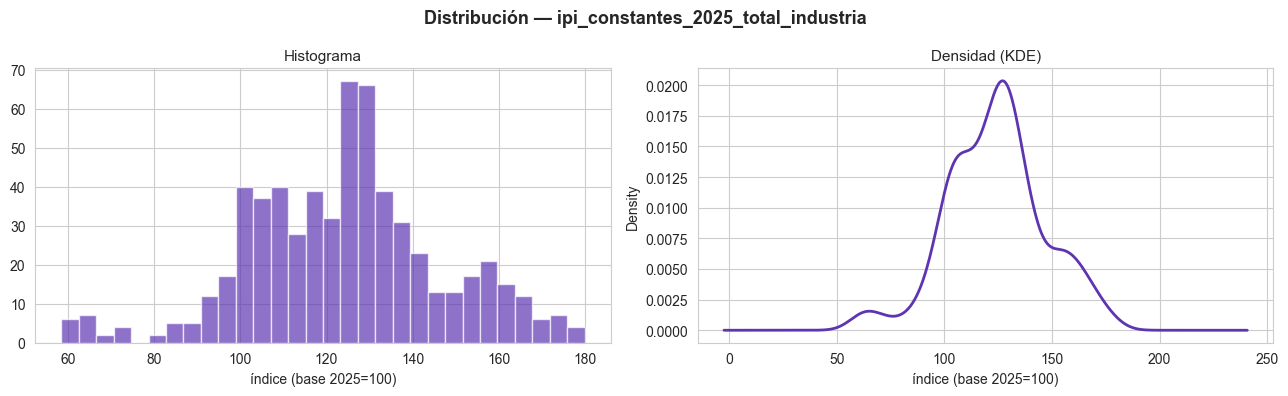

Asimetría (skewness): -0.098
Curtosis:             0.314


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Distribución — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].hist(y, bins=30, color=COLOR_PRINCIPAL, alpha=0.7, edgecolor='white')
axes[0].set_xlabel(UNIDADES, fontsize=10)
axes[0].set_title('Histograma', fontsize=11)

y.plot.kde(ax=axes[1], color=COLOR_PRINCIPAL, lw=2)
axes[1].set_xlabel(UNIDADES, fontsize=10)
axes[1].set_title('Densidad (KDE)', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Asimetría (skewness): {y.skew():.3f}')
print(f'Curtosis:             {y.kurtosis():.3f}')

### Análisis:

La distribución del `ipi_constantes_2025_total_industria` es notablemente más simétrica que la de las variables de precio analizadas: la asimetría es de -0,098, prácticamente nula, y la curtosis de 0,314 es ligeramente positiva pero próxima a la de una distribución normal. Esta forma refleja que la producción industrial, a diferencia de los índices de precios o del tipo de cambio, ha pasado tiempo relativamente repartido a lo largo de su rango, sin una concentración marcada en un régimen ni colas extremas pronunciadas.

El cuerpo de la distribución se sitúa entre aproximadamente 100 y 150, recogiendo los niveles de la expansión de los años 90 y 2000 y de la meseta post-crisis, con una dispersión amplia que incorpora la fuerte variación estacional de la serie: las caídas de agosto generan una masa de observaciones en la parte baja del rango que contrarresta el sesgo que de otro modo introduciría la tendencia ascendente. La cercanía de la asimetría a cero es, en buena medida, consecuencia de esta estacionalidad pronunciada. Para la modelización, el nivel no es adecuado como variable directa por su no estacionariedad y su estacionalidad; la variación interanual, que se adopta como forma estacionaria, elimina ambas.

In [12]:
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
limite_inf_iqr = Q1 - 1.5 * IQR
limite_sup_iqr = Q3 + 1.5 * IQR

z_scores = np.abs(stats.zscore(y.dropna()))
outliers_z = y[z_scores > 3]
outliers_iqr = y[(y < limite_inf_iqr) | (y > limite_sup_iqr)]

print(f'Outliers por IQR  (1.5×): {len(outliers_iqr)}')
print(f'Outliers por z-score (>3): {len(outliers_z)}')

extremos = pd.concat([
    y.nsmallest(5).rename('valor'),
    y.nlargest(5).rename('valor')
]).sort_values()

print('\n10 valores extremos (5 mínimos + 5 máximos):')
print(extremos.to_frame().reset_index().to_string(index=False))

Outliers por IQR  (1.5×): 17
Outliers por z-score (>3): 0

10 valores extremos (5 mínimos + 5 máximos):
     fecha   valor
1982-08-01  58.397
1981-08-01  59.324
1975-08-01  59.787
1983-08-01  61.333
1980-08-01  61.487
2007-06-01 174.420
2007-10-01 177.510
2007-05-01 177.819
2006-03-01 178.127
2007-03-01 179.982


### Análisis:

El `ipi_constantes_2025_total_industria` presenta 17 outliers por criterio IQR y ninguno por z-score, una combinación que tiene una causa directa y reveladora: los outliers por IQR no son anomalías sino los mínimos estacionales de agosto, que la fuerte caída del verano industrial sitúa de forma recurrente por debajo del bigote inferior de la distribución. Que el z-score no detecte ninguno confirma que estos valores, aunque extremos respecto al cuerpo de la distribución, están dentro de las tres desviaciones típicas y forman parte del patrón regular de la serie.

Los diez valores extremos lo confirman: los cinco mínimos corresponden todos al mes de agosto (1982, 1981, 1975, 1983 y 1980, entre 58,40 y 61,49), los meses de menor actividad fabril en el periodo de tipos de producción más bajos, y los cinco máximos al pico industrial de 2006-2007 (entre 174,42 y 179,98), justo antes del colapso de la crisis financiera. Ninguno es una anomalía de medición: los mínimos son la estacionalidad de agosto y los máximos el techo histórico de la producción industrial española, dos rasgos genuinos de la serie.

In [13]:
if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
    y_periodo = y.index.quarter.map({1:'T1', 2:'T2', 3:'T3', 4:'T4'})
    titulo_grupo = 'Trimestre'
    orden_periodos = ['T1', 'T2', 'T3', 'T4']
elif DATASET_CONFIG['frecuencia_original'] == 'mensual':
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses
else:
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses

colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
               '#1565C0', '#AD1457', '#2E7D32', '#E65100',
               '#6A1B9A', '#00695C', '#F57F17', '#37474F']

df_box = pd.DataFrame({
    'periodo': y_periodo.values,
    'valor': y.values,
    'fecha': y.index.strftime('%Y-%m-%d'),
})
df_box['periodo'] = pd.Categorical(df_box['periodo'],
                                    categories=[p for p in orden_periodos if p in df_box['periodo'].values],
                                    ordered=True)

fig = px.box(
    df_box, x='periodo', y='valor', color='periodo',
    hover_data=['fecha'],
    title=f'Distribución por {titulo_grupo} — {VAR_PRINCIPAL}',
    labels={'valor': UNIDADES, 'periodo': titulo_grupo, 'fecha': 'Fecha'},
    color_discrete_sequence=colores_bp,
    category_orders={'periodo': orden_periodos},
)
fig.update_layout(showlegend=False, height=420)
fig.show()

### Análisis:

La distribución por mes del `ipi_constantes_2025_total_industria` revela la estacionalidad más marcada de todas las variables del proyecto. Once de las doce cajas son similares, con medianas en torno a 120-130, pero el mes de **agosto se desploma** de forma inequívoca: su mediana cae a aproximadamente 85-90 y toda su caja se desplaza muy por debajo del resto, reflejo del cierre estival generalizado de la actividad fabril española, cuando buena parte de la industria detiene la producción por vacaciones. Marzo, octubre y noviembre muestran los niveles algo más altos, asociados a los meses de mayor actividad productiva.

Esta estacionalidad no es un artefacto sino un patrón económico genuino y de gran amplitud, a diferencia de los índices de precios, el tipo de cambio o el tipo de interés, donde era negligible. Su magnitud, con agosto entre 15 y 35 puntos por debajo de los demás meses, implica que el nivel y la primera diferencia de la serie arrastran un componente estacional fuerte, y que la transformación de referencia para el cruce con el paro debe ser interanual, comparando cada periodo con el mismo del año anterior, para neutralizarlo.

---
## 4. Estacionalidad

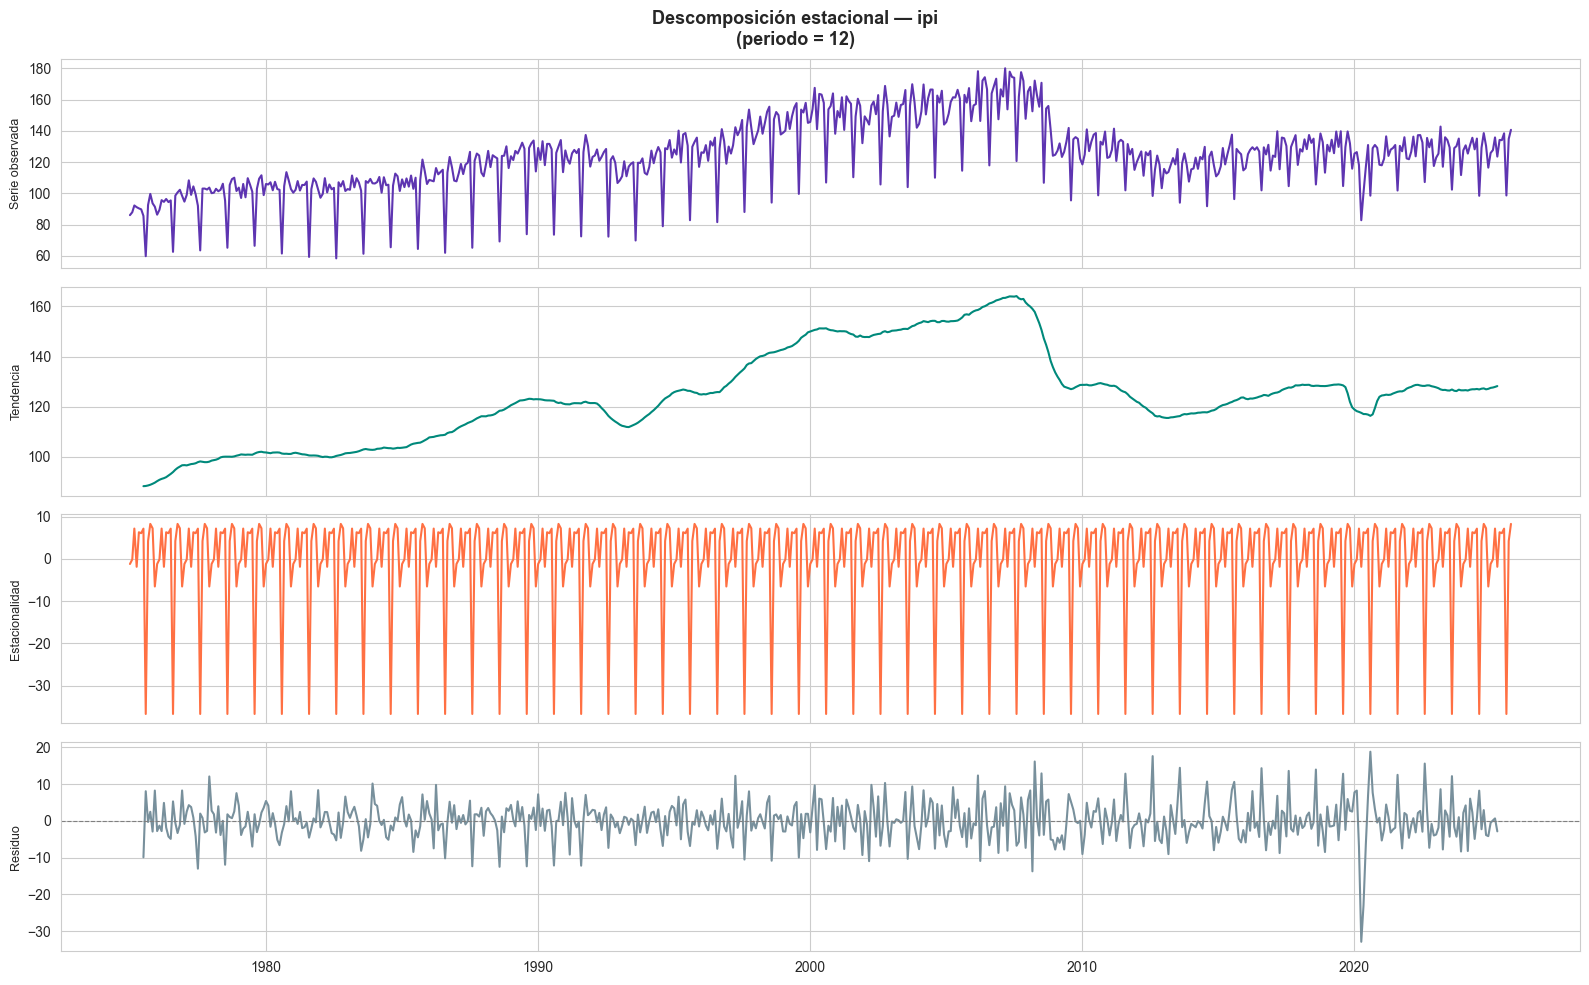

In [14]:
y_descomp = y.dropna()

if len(y_descomp) >= 2 * PERIODO_ESTACIONAL:
    descomp = seasonal_decompose(y_descomp, model='additive', period=PERIODO_ESTACIONAL)

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Descomposición estacional — {NOMBRE}\n(periodo = {PERIODO_ESTACIONAL})',
                 fontsize=13, fontweight='bold')

    componentes = [
        ('Serie observada', descomp.observed, COLOR_PRINCIPAL),
        ('Tendencia', descomp.trend, '#00897B'),
        ('Estacionalidad', descomp.seasonal, '#FF7043'),
        ('Residuo', descomp.resid, '#78909C'),
    ]

    for ax, (titulo, datos, color) in zip(axes, componentes):
        ax.plot(datos.index, datos, color=color, lw=1.5)
        ax.set_ylabel(titulo, fontsize=9)
        if titulo == 'Residuo':
            ax.axhline(0, color='gray', linestyle='--', lw=0.8)

    plt.tight_layout()
    plt.show()
else:
    print(f'Serie demasiado corta para descomposición (necesita ≥ {2*PERIODO_ESTACIONAL} obs, tiene {len(y_descomp)})')

### Análisis:

La descomposición STL con periodo 12 confirma cuantitativamente que el `ipi_constantes_2025_total_industria` es la variable más estacional del proyecto. El componente estacional es de amplitud muy grande y regular, dominado por el desplome de agosto, con un recorrido del orden de 30-40 puntos entre el máximo y el mínimo estacional, sobre una serie que oscila en torno a 120. Esta amplitud, sin equivalente en las demás variables, hace imprescindible su tratamiento.

La tendencia replica la dinámica de fondo ya documentada: crecimiento sostenido hasta el pico de 2007, colapso de 2008-2013 y recuperación parcial a una meseta inferior. El componente residual permanece contenido durante la mayor parte de la muestra y solo se dispara en los dos grandes shocks, la crisis financiera de 2008-2009 y el confinamiento de 2020, los únicos episodios en que la caída de la producción excede lo que tendencia y estacionalidad capturan conjuntamente. La regularidad y amplitud del componente estacional confirman que la primera diferencia, aunque estacionaria, conservará la estructura de periodo 12, y que la variación interanual es la transformación que la elimina de forma natural.

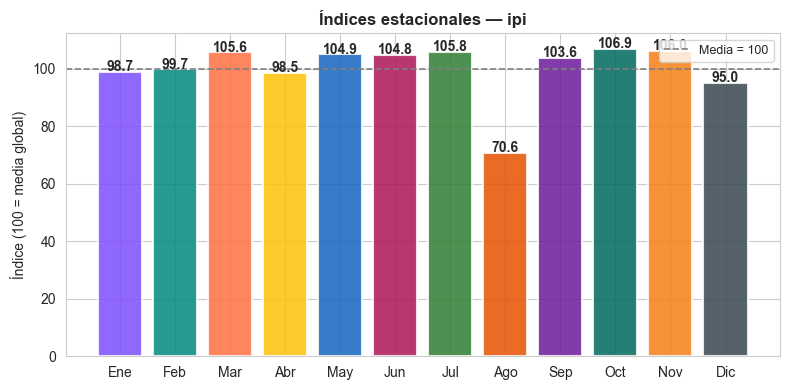

Índices estacionales:
Ene    98.700
Feb    99.700
Mar   105.600
Abr    98.500
May   104.900
Jun   104.800
Jul   105.800
Ago    70.600
Sep   103.600
Oct   106.900
Nov   106.000
Dic    95.000

Periodo con mayor ipi: Oct (106.9)
Periodo con menor ipi: Ago (70.6)


In [15]:
if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):

    if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
        grupo_idx = y.index.quarter
        etiq_idx = ['T1', 'T2', 'T3', 'T4']
    else:
        grupo_idx = y.index.month
        etiq_idx = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

    media_por_periodo = pd.Series(
        {p: y[grupo_idx == p].mean() for p in sorted(np.unique(grupo_idx))}
    )
    indice_estacional = (media_por_periodo / media_por_periodo.mean() * 100).round(1)
    indice_estacional.index = etiq_idx[:len(indice_estacional)]

    fig, ax = plt.subplots(figsize=(8, 4))
    colores_idx = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
                   '#1565C0', '#AD1457', '#2E7D32', '#E65100',
                   '#6A1B9A', '#00695C', '#F57F17', '#37474F']
    barras = ax.bar(indice_estacional.index, indice_estacional.values,
                    color=colores_idx[:len(indice_estacional)], edgecolor='white',
                    linewidth=1.5, alpha=0.85)
    ax.axhline(100, color='gray', linestyle='--', lw=1.2, label='Media = 100')
    ax.set_title(f'Índices estacionales — {NOMBRE}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Índice (100 = media global)', fontsize=10)
    for b, v in zip(barras, indice_estacional.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Índices estacionales:')
    print(indice_estacional.to_string())
    print(f'\nPeriodo con mayor {NOMBRE}: {indice_estacional.idxmax()} ({indice_estacional.max():.1f})')
    print(f'Periodo con menor {NOMBRE}: {indice_estacional.idxmin()} ({indice_estacional.min():.1f})')

### Análisis:

Los índices estacionales cuantifican con precisión el patrón anticipado: el rango entre el mes de mayor producción (octubre, 106,9) y el de menor (agosto, 70,6) es de 36,3 puntos porcentuales sobre la media global, la amplitud estacional más elevada de todas las variables analizadas, muy por encima de la del PIB (5,3 puntos) y de la práctica ausencia de estacionalidad de los precios.

El perfil es nítido: la actividad se mantiene en torno a la media durante la mayor parte del año, con máximos en marzo (105,6), julio (105,8), octubre (106,9) y noviembre (106,0), y se desploma en agosto (70,6), casi 30 puntos por debajo de la media, por el cierre estival generalizado de la industria española. Diciembre también queda algo por debajo (95,0) por el efecto de las fiestas navideñas. Esta estacionalidad, a diferencia de la del resto de variables, no es prescindible en absoluto: un índice que cae casi un tercio en agosto introduciría una variación espuria muy grande si se usara sin corregir. La transformación adoptada, la variación interanual de la producción, elimina automáticamente este componente al comparar cada mes con el mismo del año anterior.

---
## 5. Cambios Periodo a Periodo

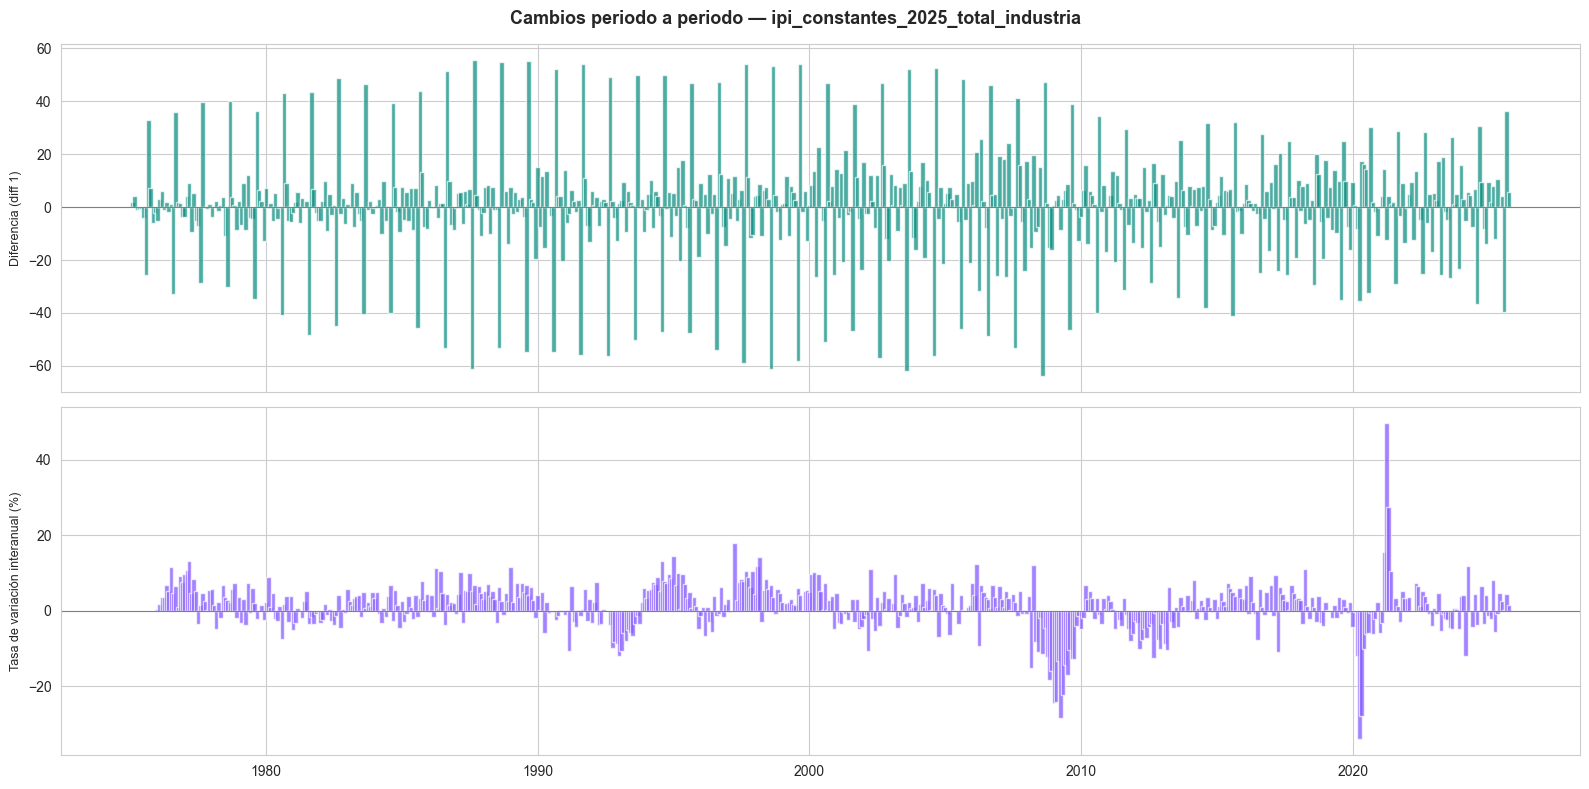

Estadísticas de la variación interanual (%):
count   598.000
mean      0.960
std       6.350
min     -34.120
25%      -2.130
50%       1.230
75%       4.580
max      49.670


In [16]:
diff1 = y.diff(1).dropna()
diff_est = ((y / y.shift(PERIODO_ESTACIONAL) - 1) * 100).dropna()  # variación interanual %  # se usa en Sección 6 (stationarity test)
pct_yoy = y.pct_change(PERIODO_ESTACIONAL).dropna() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Cambios periodo a periodo — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].bar(diff1.index, diff1, color='#00897B', alpha=0.7, width=60)
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_ylabel('Diferencia (diff 1)', fontsize=9)

axes[1].bar(pct_yoy.index, pct_yoy, color='#7C4DFF', alpha=0.7, width=60)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_ylabel('Tasa de variación interanual (%)', fontsize=9)

plt.tight_layout()
plt.show()

print('Estadísticas de la variación interanual (%):')
print(pct_yoy.describe().round(2).to_string())

### Análisis:

La diferencia mensual del `ipi_constantes_2025_total_industria` (panel superior) está dominada por la estacionalidad: presenta oscilaciones regulares de gran amplitud que corresponden a las caídas y recuperaciones de agosto, lo que confirma que la primera diferencia ordinaria no elimina el componente estacional de periodo 12 y la hace inadecuada como transformación directa para esta serie.

La variación interanual (panel inferior) ofrece la perspectiva relevante y neutraliza la estacionalidad. Su distribución refleja el carácter cíclico de la producción industrial: media de 0,96%, mediana de 1,23% y una desviación típica de 6,35%, con un rango que va desde -34,12% (el desplome del confinamiento de 2020 y la crisis financiera) hasta +49,67% (los rebotes post-recesión). La proximidad de la media y la mediana a cero, junto a la simetría relativa del rango, indica que el crecimiento interanual de la producción revierte en torno a una media próxima a cero, propia de una serie sin crecimiento exponencial. Esta variación interanual porcentual es la transformación adoptada para el cruce con el paro: estacionaria, libre de estacionalidad, homocedástica e interpretable como crecimiento de la producción industrial, el indicador macro estándar.

---
## 6. Estacionariedad y Autocorrelación

In [17]:
def test_estacionariedad(serie, nombre_serie, regression='c'):
    s = serie.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags='auto')
    estacionaria = (adf_p < 0.05) and (kpss_p >= 0.05)
    return {
        'serie': nombre_serie,
        'regression': regression,
        'ADF_stat': round(adf_stat, 4),
        'ADF_p': round(adf_p, 4),
        'ADF_H0_rechaza': adf_p < 0.05,
        'KPSS_stat': round(kpss_stat, 4),
        'KPSS_p': round(kpss_p, 4),
        'KPSS_H0_rechaza': kpss_p < 0.05,
        'conclusion': 'ESTACIONARIA' if estacionaria else 'NO ESTACIONARIA',
    }

series_test = [
    (y, f'{VAR_PRINCIPAL} (nivel)', 'c'),
    (diff1, f'{VAR_PRINCIPAL} (diff 1)', 'c'),
    (diff_est, f'{VAR_PRINCIPAL} (var interanual %)', 'c'),
]

resultados_est = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test])

print('Tests de estacionariedad:')
print('=' * 85)
print(resultados_est.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_est.iterrows():
    h0_adf = 'rechaza H\u2080' if row['ADF_H0_rechaza'] else 'NO rechaza H\u2080'
    h0_kpss = 'rechaza H\u2080' if row['KPSS_H0_rechaza'] else 'NO rechaza H\u2080'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  (H\u2080 = ra\u00edz unitaria):  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS (H\u2080 = estacionaria):   stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    \u2192 {row['conclusion']}")
    print()

Tests de estacionariedad:
                                                 serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
           ipi_constantes_2025_total_industria (nivel)          c    -1.944  0.312           False      1.606   0.010             True NO ESTACIONARIA
          ipi_constantes_2025_total_industria (diff 1)          c    -5.686  0.000            True      0.029   0.100            False    ESTACIONARIA
ipi_constantes_2025_total_industria (var interanual %)          c    -4.802  0.000            True      0.327   0.100            False    ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  ipi_constantes_2025_total_industria (nivel)  (KPSS regression='c')
    ADF  (H₀ = raíz unitaria):  stat=-1.944, p=0.3116 (NO rechaza H₀)
    KPSS (H₀ = estacionaria):   stat=1.606, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  ipi_constantes_2025_total_industria (diff 1)  (KPSS regression='c')
    AD

### Análisis:

En niveles, ambos tests convergen en un diagnóstico claro de no estacionariedad: el ADF no rechaza la raíz unitaria (stat=-1,944, p=0,3120) y el KPSS rechaza la estacionariedad (stat=1,606, p=0,0100), resultado esperado para una serie con tendencia ascendente dominante.

La primera diferencia produce un diagnóstico estadísticamente limpio: el ADF rechaza la raíz unitaria (stat=-5,686, p=0,0000) y el KPSS no rechaza la estacionariedad (stat=0,029, p=0,1000). La variación interanual porcentual también es estacionaria (ADF stat=-4,802, p=0,0000; KPSS stat=0,327, p=0,1000). Ahora bien, esta convergencia de los tests no debe leerse como equivalencia entre ambas transformaciones: como muestran el correlograma y la descomposición, la primera diferencia conserva intacta la fuerte estacionalidad de periodo 12 de la serie, mientras la variación interanual la elimina. Para una serie tan estacional como el IPI, la diferencia ordinaria no es una transformación adecuada pese a pasar los tests de raíz unitaria, y la caracterización operativa a frecuencia trimestral se valida en el bloque 6.1, donde se confirma la elección de la variación interanual.

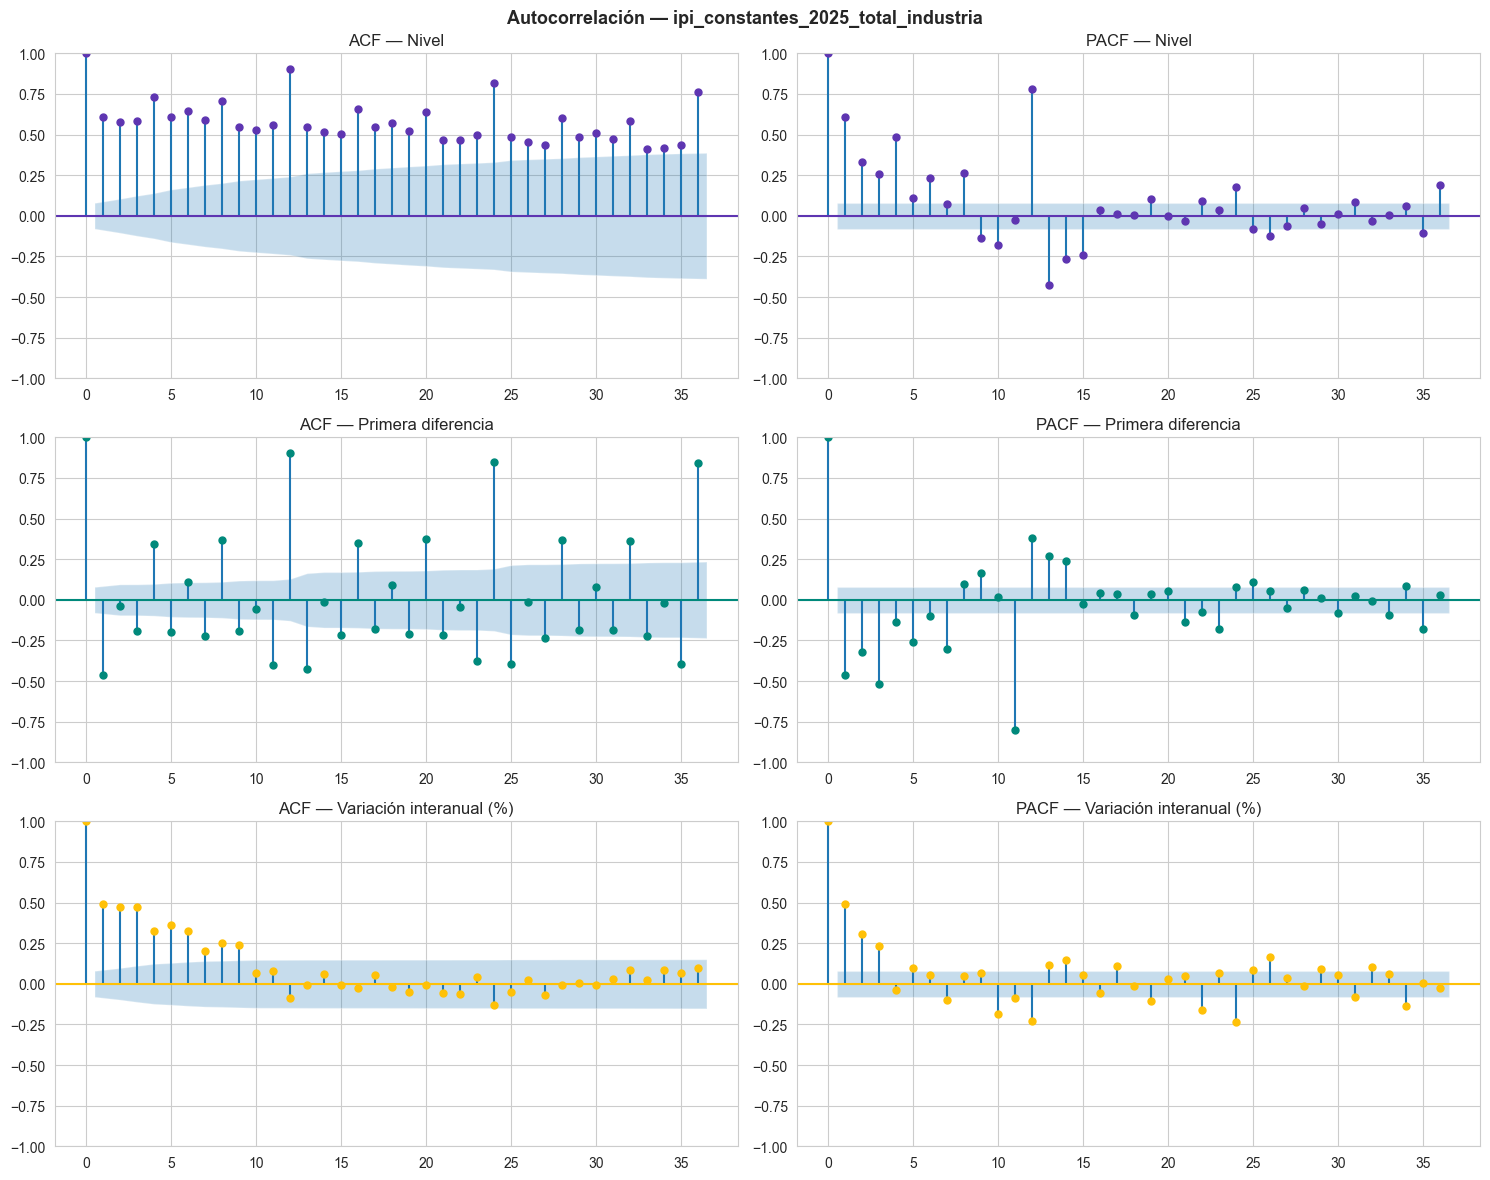

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle(f'Autocorrelación — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel')
plot_pacf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel', method='ywm')
plot_acf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 0], color='#00897B',
         title='ACF — Primera diferencia')
plot_pacf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 1], color='#00897B',
          title='PACF — Primera diferencia', method='ywm')
plot_acf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 0], color='#FFC107',
         title='ACF — Variación interanual (%)')
plot_pacf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 1], color='#FFC107',
          title='PACF — Variación interanual (%)', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

En niveles, el correlograma presenta el patrón de serie no estacionaria: la ACF decae lentamente manteniéndose próxima a 1 a lo largo del espectro y la PACF concentra la señal en un pico dominante en el lag 1, coherente con la tendencia y los tests.

Tras la primera diferencia, el correlograma revela el rasgo distintivo de esta serie: una estructura estacional muy marcada que la diferencia ordinaria no elimina. La ACF muestra picos negativos fuertes en el lag 1 y, sobre todo, una alternancia con picos significativos a múltiplos de 12 (lags 12, 24), la firma inequívoca de la estacionalidad mensual de periodo 12 que la primera diferencia conserva intacta. La PACF replica esta lectura con estructura en los lags estacionales. Este patrón confirma visualmente lo que la descomposición STL y el boxplot ya establecían: la diff 1 sustrae la tendencia pero deja la fuerte estacionalidad del verano industrial, por lo que no es una transformación adecuada para esta variable. La diferencia interanual, que se evalúa a frecuencia trimestral en el bloque siguiente, es la que elimina la estructura estacional al comparar cada periodo con el del año anterior.

### 6.1 Validación a frecuencia trimestral

El bloque previo de tests caracteriza la serie a su frecuencia original, donde la información es más rica. La modelización del paro, sin embargo, opera a frecuencia trimestral (target EPA), por lo que las transformaciones operativas deben validarse a esa misma frecuencia.

Este bloque verifica que las conclusiones sobre estacionariedad se trasladan correctamente a la serie resampleada (por media trimestral, coherente con la naturaleza de la variable), sobre la que opera el modelo. Se evalúan las mismas cuatro transformaciones que a frecuencia original:
- nivel trimestral
- `Δ1` trimestral (cambio intertrimestral)
- `Δ4` trimestral (cambio interanual)
- variación interanual porcentual trimestral

In [19]:
# Resampleo a frecuencia trimestral
LAGS_ACF_Q = 16
METODO_Q = 'media'
y_q = df[VAR_PRINCIPAL].resample('QS').mean().dropna()

diff1_q = y_q.diff(1).dropna()
diff4_q = y_q.diff(4).dropna()
pct_q = ((y_q / y_q.shift(4) - 1) * 100).dropna()

series_test_q = [
    (y_q, f'{VAR_PRINCIPAL} trimestral (nivel)', 'ct'),
    (diff1_q, f'{VAR_PRINCIPAL} trimestral (Δ1)', 'c'),
    (diff4_q, f'{VAR_PRINCIPAL} trimestral (Δ4)', 'c'),
    (pct_q, f'{VAR_PRINCIPAL} trimestral (var interanual %)', 'c'),
]

resultados_q = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test_q])

print(f'Tests de estacionariedad — frecuencia TRIMESTRAL (resampleo: {METODO_Q}):')
print('=' * 85)
print(resultados_q.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_q.iterrows():
    h0_adf = 'rechaza H₀' if row['ADF_H0_rechaza'] else 'NO rechaza H₀'
    h0_kpss = 'rechaza H₀' if row['KPSS_H0_rechaza'] else 'NO rechaza H₀'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    → {row['conclusion']}")
    print()

Tests de estacionariedad — frecuencia TRIMESTRAL (resampleo: media):
                                                            serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
           ipi_constantes_2025_total_industria trimestral (nivel)         ct    -1.786  0.388           False      0.399   0.010             True NO ESTACIONARIA
              ipi_constantes_2025_total_industria trimestral (Δ1)          c    -3.546  0.007            True      0.111   0.100            False    ESTACIONARIA
              ipi_constantes_2025_total_industria trimestral (Δ4)          c    -3.260  0.017            True      0.232   0.100            False    ESTACIONARIA
ipi_constantes_2025_total_industria trimestral (var interanual %)          c    -3.226  0.018            True      0.284   0.100            False    ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  ipi_constantes_2025_total_industria trimestral (nivel

### Análisis:

La validación a frecuencia trimestral confirma el diagnóstico de la frecuencia mensual. El nivel sigue siendo no estacionario (ADF stat=-1,786, p=0,3880; KPSS stat=0,399, p=0,0100). Las tres formas diferenciadas son estacionarias: la primera diferencia `Δ1` (ADF stat=-3,546, p=0,0070; KPSS stat=0,111, p=0,1000), la diferencia interanual `Δ4` (ADF stat=-3,260, p=0,0170; KPSS stat=0,232, p=0,1000) y la variación interanual porcentual (ADF stat=-3,226, p=0,0180; KPSS por debajo del umbral de rechazo).

La elección de la forma, sin embargo, no la deciden solo los p-valores. La `Δ1` es estacionaria pero, como muestran los correlogramas, conserva la fuerte estacionalidad de periodo 4 de la producción industrial, lo que la hace inadecuada. Las transformaciones interanuales (`Δ4` y variación porcentual) eliminan a la vez tendencia y estacionalidad. Entre ellas se adopta la variación interanual porcentual, el crecimiento de la producción industrial, por las mismas razones que en el PIB: es homocedástica al normalizar por el nivel, de escala homogénea y comparable para la selección de variables con Ridge y Lasso y para los modelos econométricos, y es el indicador macro canónico de la actividad industrial.

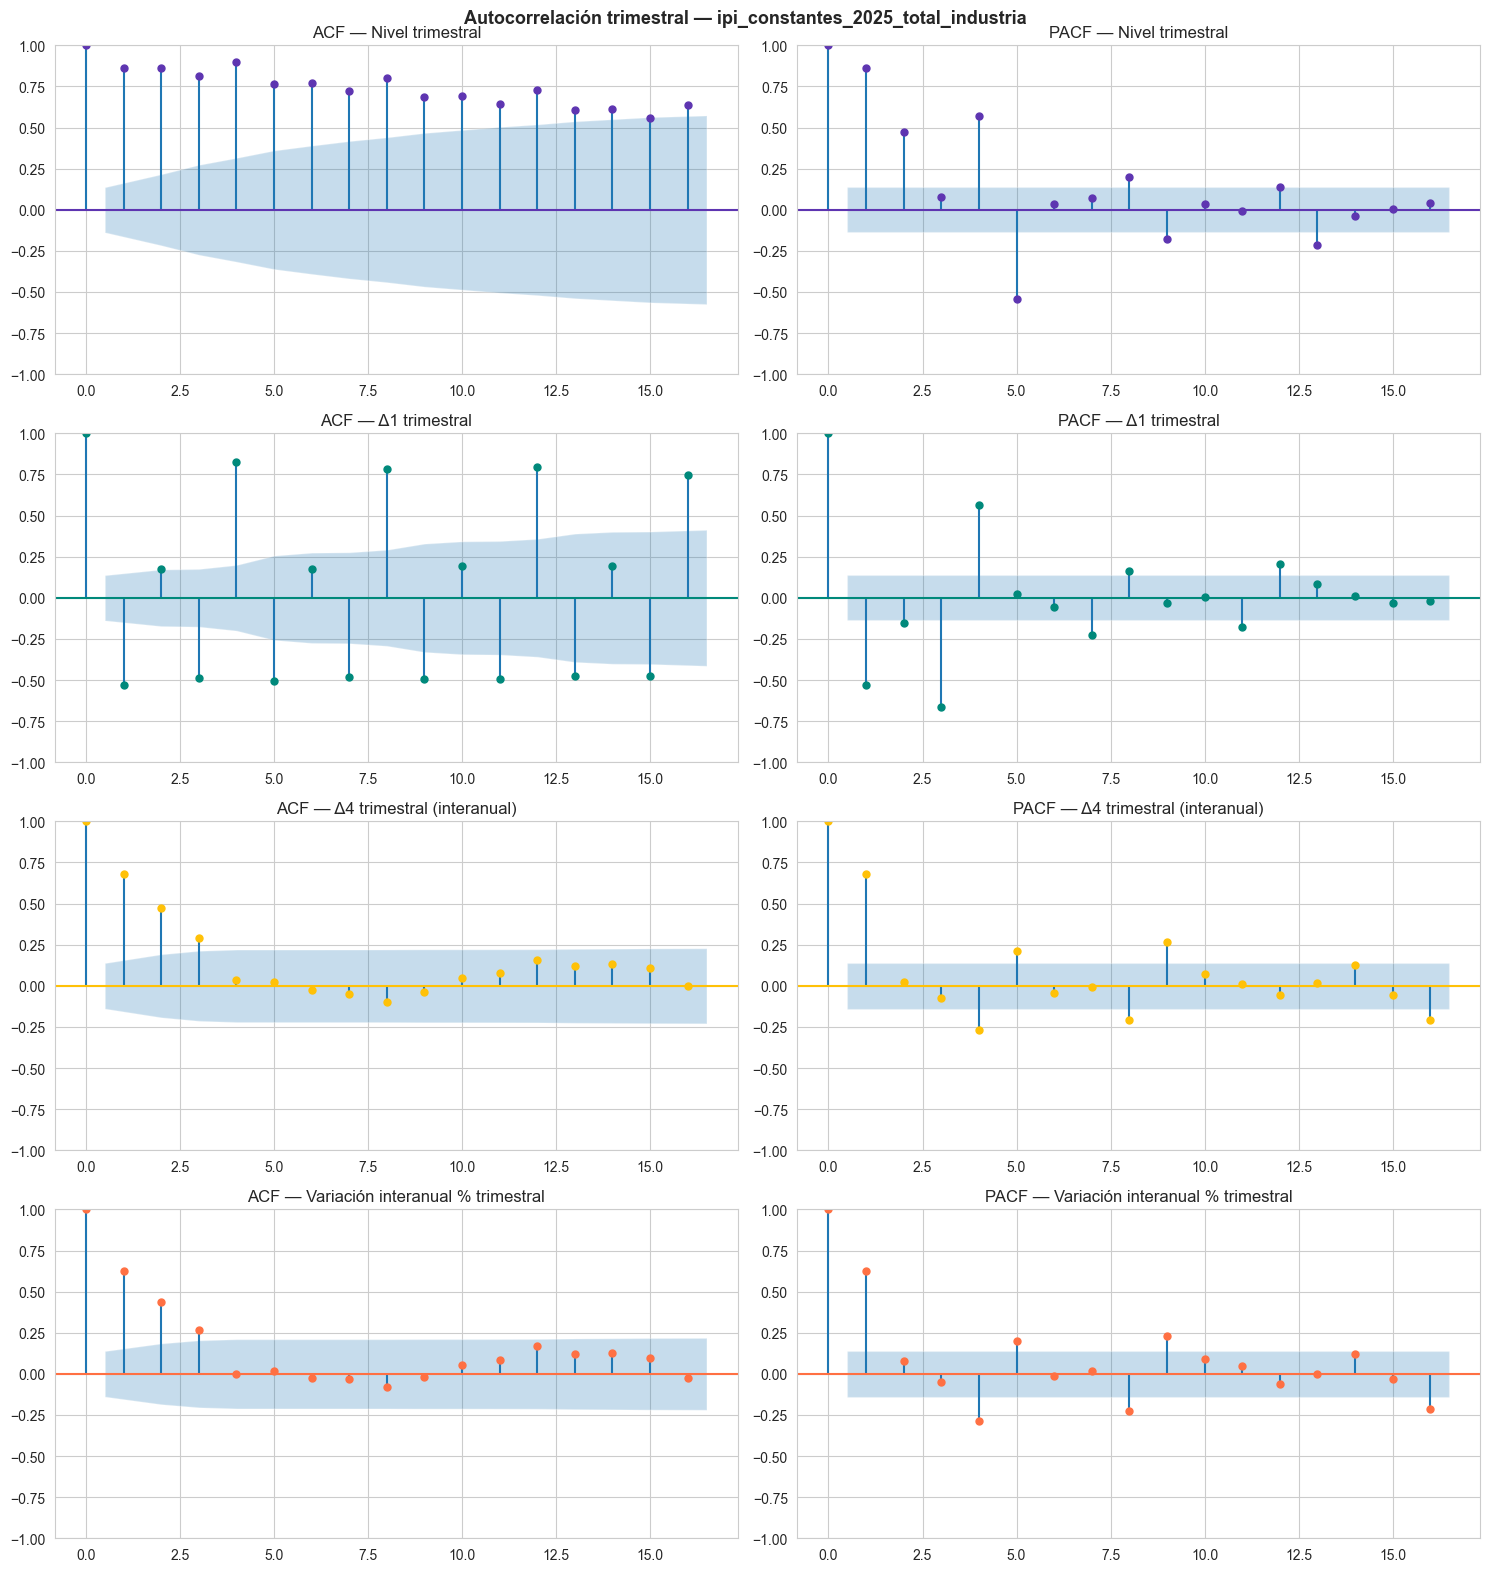

In [20]:
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
fig.suptitle(f'Autocorrelación trimestral — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y_q.dropna(), lags=LAGS_ACF_Q, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel trimestral')
plot_pacf(y_q.dropna(), lags=LAGS_ACF_Q, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel trimestral', method='ywm')
plot_acf(diff1_q, lags=LAGS_ACF_Q, ax=axes[1, 0], color='#00897B',
         title='ACF — Δ1 trimestral')
plot_pacf(diff1_q, lags=LAGS_ACF_Q, ax=axes[1, 1], color='#00897B',
          title='PACF — Δ1 trimestral', method='ywm')
plot_acf(diff4_q, lags=LAGS_ACF_Q, ax=axes[2, 0], color='#FFC107',
         title='ACF — Δ4 trimestral (interanual)')
plot_pacf(diff4_q, lags=LAGS_ACF_Q, ax=axes[2, 1], color='#FFC107',
          title='PACF — Δ4 trimestral (interanual)', method='ywm')
plot_acf(pct_q, lags=LAGS_ACF_Q, ax=axes[3, 0], color='#FF7043',
         title='ACF — Variación interanual % trimestral')
plot_pacf(pct_q, lags=LAGS_ACF_Q, ax=axes[3, 1], color='#FF7043',
          title='PACF — Variación interanual % trimestral', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

La estructura de autocorrelación a frecuencia trimestral confirma el diagnóstico de los tests y de la frecuencia mensual. En nivel, la ACF decae lentamente desde valores próximos a 1 y la PACF concentra la señal en un pico dominante en el lag 1, el patrón de un AR(1) con raíz próxima a 1 propio de una serie no estacionaria.

La primera diferencia `Δ1` mantiene una estructura estacional residual de periodo 4, con picos en los lags múltiplos de 4 que reflejan la estacionalidad trimestral heredada del fuerte patrón mensual, lo que confirma que no estabiliza del todo la serie pese a pasar los tests. La diferencia interanual `Δ4` y la variación interanual porcentual presentan un perfil más limpio en cuanto a estacionalidad, al haberla eliminado por construcción, aunque con cierta persistencia en los primeros lags propia del solapamiento interanual. Las tres son estacionarias según los tests, pero solo las interanuales eliminan la estacionalidad; entre ellas se adopta la variación interanual porcentual por su homocedasticidad e interpretación económica.

In [21]:
# Estacionalidad trimestral reconstruida desde y_q
if len(y_q) >= 8:
    colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107']
    df_box_q = pd.DataFrame({
        'trimestre': y_q.index.quarter.map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}),
        'valor': y_q.values,
        'fecha': y_q.index.strftime('%Y-%m-%d'),
    })
    df_box_q['trimestre'] = pd.Categorical(df_box_q['trimestre'],
                                            categories=['Q1', 'Q2', 'Q3', 'Q4'], ordered=True)
    fig = px.box(
        df_box_q, x='trimestre', y='valor', color='trimestre',
        hover_data=['fecha'],
        title=f'Estacionalidad trimestral — {VAR_PRINCIPAL}',
        labels={'valor': UNIDADES, 'trimestre': 'Trimestre'},
        color_discrete_sequence=colores_bp,
    )
    fig.update_layout(showlegend=False, height=420)
    fig.show()

    medias_q = y_q.groupby(y_q.index.quarter).mean()
    cv_trimestral = medias_q.std() / medias_q.mean() * 100 if medias_q.mean() != 0 else 0
    medias_dict = {k: round(float(v), 3) for k, v in medias_q.items()}
    print('Media por trimestre:', medias_dict)
    estac = '(estacionalidad apreciable)' if cv_trimestral > 5 else '(estacionalidad leve)'
    print(f'CV entre trimestres: {cv_trimestral:.2f}% {estac}')

Media por trimestre: {1: 125.717, 2: 127.465, 3: 115.81, 4: 127.539}
CV entre trimestres: 4.52% (estacionalidad leve)


### Análisis:

La estacionalidad de la serie resampleada a frecuencia trimestral es mucho más atenuada que la mensual, porque el resampleo por media diluye el desplome de agosto dentro del tercer trimestre. Las medias por trimestre son Q1 125,717, Q2 127,465, Q3 115,810 y Q4 127,539, con un coeficiente de variación entre trimestres del 4,52%, calificado como estacionalidad leve pero el más alto de las variables del proyecto. El tercer trimestre (Q3) queda claramente por debajo del resto, en torno a doce puntos por debajo de Q4, recogiendo el efecto del parón estival de agosto. Aun así, la amplitud trimestral es modesta comparada con la mensual (donde agosto caía 36 puntos), lo que confirma que el resampleo trimestral suaviza la estacionalidad pero no la elimina del todo. La transformación interanual adoptada para el cruce con el paro neutraliza por completo este componente residual.

---
## 7. Variables Derivadas Intra-Dataset
Ratios y transformaciones calculadas a partir de las columnas de este dataset.

In [22]:
df_der = pd.DataFrame(index=df.index)

col_equipo = 'ipi_constantes_2025_bienes_equipo'
col_consumo = 'ipi_constantes_2025_bienes_consumo'
col_total = 'ipi_constantes_2025_total_industria'

if col_equipo in df.columns and col_consumo in df.columns:
    df_der['ratio_equipo_consumo'] = df[col_equipo] / df[col_consumo]

if col_total in df.columns:
    df_der['crecimiento_ipi_yoy'] = df[col_total].pct_change(12) * 100
    df_der['indice_relativo_ipi'] = df[col_total] / df[col_total].mean() * 100

print(f'Variables derivadas creadas ({len(df_der.columns)}):')
display(df_der.describe().round(3))

Variables derivadas creadas (3):


,ratio_equipo_consumo,crecimiento_ipi_yoy,indice_relativo_ipi
count,610.000,598.000,610.000
mean,1.214,0.963,100.000
std,0.543,6.353,18.139
min,0.250,-34.122,47.065
25%,0.954,-2.134,87.281
50%,1.065,1.232,100.649
75%,1.219,4.584,109.553
max,3.750,49.667,145.054


### Análisis:

Se han construido tres variables derivadas del IPI, cada una orientada a capturar una dimensión distinta de la estructura productiva. `ratio_equipo_consumo` (cociente entre la producción de bienes de equipo y la de bienes de consumo) tiene una media de 1,214 y una mediana de 1,065, con un rango de 0,250 a 3,750: cuantifica el peso relativo de la inversión frente al consumo en la producción industrial, y su variabilidad recoge el declive estructural de los bienes de equipo documentado en el análisis de componentes.

`crecimiento_ipi_yoy` (variación interanual porcentual) reproduce la transformación estacionaria adoptada para el cruce con el paro: media de 0,963%, mediana de 1,232% y desviación típica de 6,353%, con un rango de -34,122% a +49,667% que recoge las grandes contracciones y rebotes de la producción. Es la transformación de referencia.

`indice_relativo_ipi` (índice normalizado con base 100 en la media de la muestra) tiene por construcción media 100, mediana 100,649 y una desviación típica de 18,139, y permite situar cada observación respecto al nivel medio de producción del periodo, facilitando la comparación de la posición cíclica.

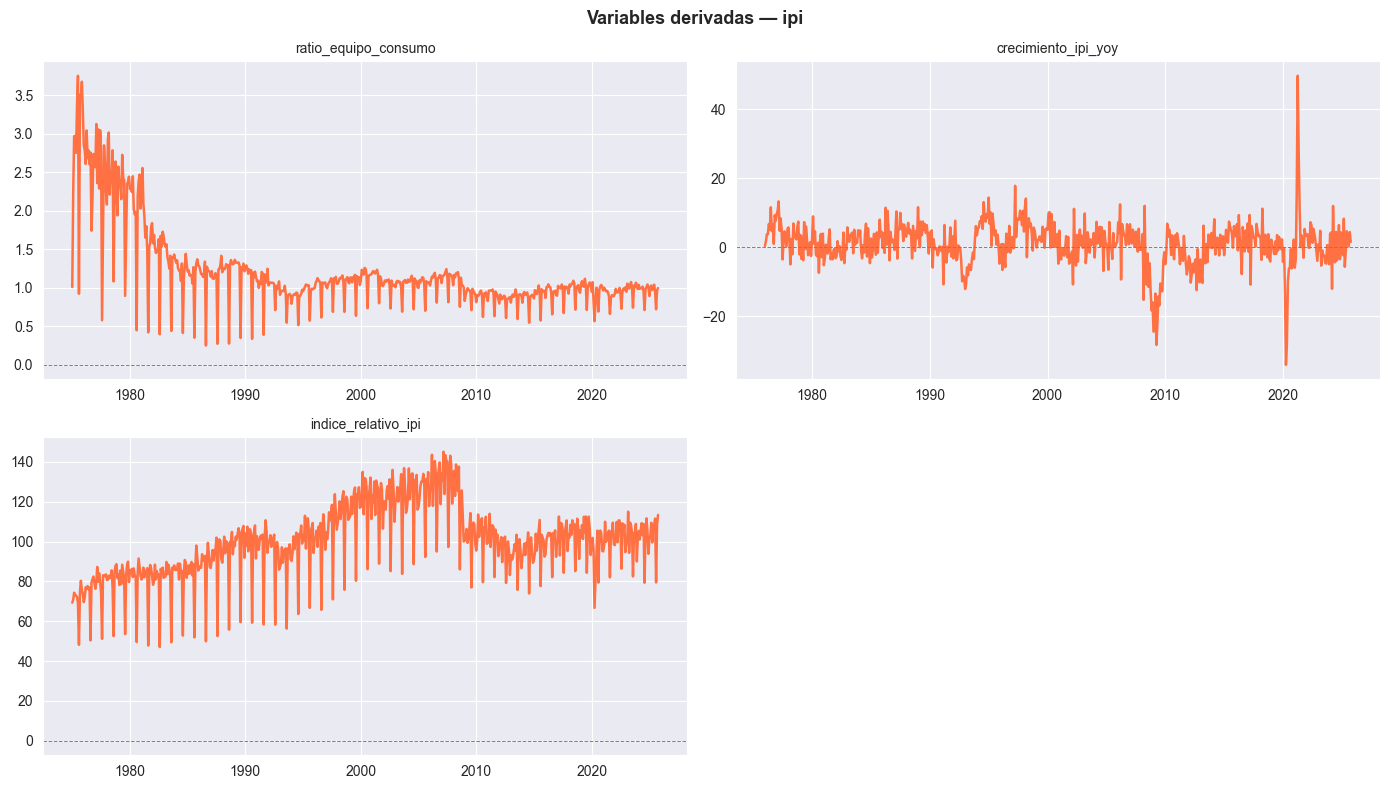

In [23]:
if not df_der.empty and len(df_der.columns) > 0:
    ncols = min(2, len(df_der.columns))
    nrows = (len(df_der.columns) + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(f'Variables derivadas — {NOMBRE}', fontsize=13, fontweight='bold')

    for ax, col in zip(axes, df_der.columns):
        serie = df_der[col].dropna()
        ax.plot(serie.index, serie, color='#FF7043', lw=1.8)
        ax.axhline(0, color='gray', lw=0.7, linestyle='--')
        ax.set_title(col, fontsize=10)

    for ax in axes[len(df_der.columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### Análisis:

La representación temporal de las tres variables derivadas confirma los estadísticos descriptivos. `ratio_equipo_consumo` describe el declive relativo de los bienes de equipo: parte de valores elevados en los años 70 y desciende de forma sostenida a medida que la producción de bienes de capital pierde peso frente a la de consumo, con repuntes cíclicos en las fases expansivas. `crecimiento_ipi_yoy` muestra las grandes oscilaciones interanuales de la producción, con los valles profundos de las recesiones de 1993, 2008-2009 y 2020 y los picos de los rebotes posteriores, sin tendencia y revirtiendo en torno a una media próxima a cero. `indice_relativo_ipi` replica la trayectoria de la serie principal expresada respecto a la media del periodo, situando el pico de 2007 en torno a 145 y la meseta reciente algo por encima de 100, lo que visualiza que la producción actual supera ligeramente la media histórica pero queda lejos del máximo previo a la crisis.

In [24]:
# ── Guardar dataset enriquecido (trimestral) ───────────────────────────────────────
if not df_der.empty:
    for col in df_der.columns:
        df[col] = df_der[col]

# Remuestrear a frecuencia trimestral
cols_num = [c for c in df.columns if df[c].dtype in ['float64', 'int64', 'float32']]
df_trimestral = df[cols_num].resample('QS').mean()
df_trimestral = df_trimestral.dropna(how='all')

# Guardar CSV trimestral
ruta_q = ruta.parent / (ruta.stem + '_trimestral.csv')
df_trimestral.to_csv(ruta_q)
print(f'CSV trimestral guardado: {ruta_q.name}')
print(f'  Columnas: {len(df_trimestral.columns)}')
print(f'  Rango: {df_trimestral.index.min().date()} — {df_trimestral.index.max().date()}')
print(f'  Observaciones: {len(df_trimestral)} trimestres')


CSV trimestral guardado: ipi_constantes_2025_1975_2026_trimestral.csv
  Columnas: 11
  Rango: 1975-01-01 — 2025-10-01
  Observaciones: 204 trimestres


---
## 8. Tabla Resumen

In [25]:
est_q_nivel = resultados_q[resultados_q['serie'].str.contains('nivel')]['conclusion'].values[0]
est_q_d1 = resultados_q[resultados_q['serie'].str.contains('Δ1')]['conclusion'].values[0]
est_q_d4 = resultados_q[resultados_q['serie'].str.contains('Δ4')]['conclusion'].values[0]
est_q_pct = resultados_q[resultados_q['serie'].str.contains('var interanual')]['conclusion'].values[0]

if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):
    idx_max = indice_estacional.idxmax()
    idx_min = indice_estacional.idxmin()
else:
    idx_max = 'N/A'
    idx_min = 'N/A'

q1q, q3q = y_q.quantile(0.25), y_q.quantile(0.75)
iqr_q = q3q - q1q
outliers_q = y_q[(y_q < q1q - 1.5 * iqr_q) | (y_q > q3q + 1.5 * iqr_q)]

resumen = pd.DataFrame([{
    'Dataset':               NOMBRE,
    'Variable':              VAR_PRINCIPAL,
    'Frecuencia':            f'trimestral (resampleo: {METODO_Q})',
    'N obs original':        f"{len(y.dropna())} ({DATASET_CONFIG['frecuencia_original']})",
    'Rango':                 f'{y_q.index.min().date()} — {y_q.index.max().date()}',
    'N obs':                 len(y_q.dropna()),
    'Media':                 y_q.mean().round(2),
    'Mediana':               y_q.median().round(2),
    'Std':                   y_q.std().round(2),
    'CV (%)':                (y_q.std() / y_q.mean() * 100).round(1),
    'Mín (fecha)':           f'{y_q.min():.1f} ({y_q.idxmin().date()})',
    'Máx (fecha)':           f'{y_q.max():.1f} ({y_q.idxmax().date()})',
    'Outliers IQR':          len(outliers_q),
    '% faltantes (original)': f'{df[VAR_PRINCIPAL].isnull().mean()*100:.1f}%',
    'Estacionaria (nivel)':            est_q_nivel,
    'Estacionaria (Δ1)':               est_q_d1,
    'Estacionaria (Δ4)':               est_q_d4,
    'Estacionaria (var interanual %)': est_q_pct,
    'Periodo más alto':      idx_max,
    'Periodo más bajo':      idx_min,
}]).T

resumen.columns = ['Valor']
print('=' * 60)
print('TABLA RESUMEN (frecuencia trimestral)')
print('=' * 60)
print(resumen.to_string())

TABLA RESUMEN (frecuencia trimestral)
                                                               Valor
Dataset                                                          ipi
Variable                         ipi_constantes_2025_total_industria
Frecuencia                             trimestral (resampleo: media)
N obs original                                         610 (mensual)
Rango                                        1975-01-01 — 2025-10-01
N obs                                                            204
Media                                                        124.130
Mediana                                                      124.000
Std                                                           19.230
CV (%)                                                        15.500
Mín (fecha)                                        79.3 (1975-07-01)
Máx (fecha)                                       169.5 (2007-01-01)
Outliers IQR                                                     

### Análisis:

La tabla resumen del `ipi_constantes_2025_total_industria` recoge los estadísticos principales sobre 610 observaciones mensuales entre enero de 1975 y octubre de 2025 (204 trimestres tras el resampleo por media). La media de 124,13 y la mediana de 124,00 son prácticamente idénticas, coherente con la asimetría casi nula documentada en la distribución, que la fuerte estacionalidad de agosto contribuye a equilibrar. El recorrido de la serie, de 58,40 a 179,98, refleja tanto la tendencia de largo plazo como la amplitud del componente estacional.

El diagnóstico de estacionariedad fija la forma de la variable, y el IPI es el caso más claro de la importancia de mirar más allá de los tests. El nivel no es estacionario. La primera diferencia es estacionaria según los tests pero conserva la fuerte estacionalidad de periodo 12, la más marcada del proyecto (agosto cae 36 puntos), lo que la hace inadecuada. La diferencia interanual y la variación interanual porcentual son estacionarias y eliminan a la vez tendencia y estacionalidad. Entre ellas se adopta la variación interanual porcentual, el crecimiento de la producción industrial, como forma de referencia para el cruce con el paro y para el panel de features, por ser homocedástica (normaliza por el nivel), de escala homogénea y comparable, idónea para Ridge y Lasso y para los modelos econométricos, y el indicador macro canónico de la actividad industrial. El nivel queda disponible para los modelos que operan sobre series no estacionarias.

---
## 9. Análisis Cruzado con Desempleo
Relación entre **Ipi** y el desempleo (EPA, desde 1976Q3).

In [26]:
ruta_parados_s9 = RUTA_BASE / 'parados_sexo_edad.csv'
df_par_s9 = pd.read_csv(ruta_parados_s9)
df_par_s9['fecha'] = pd.to_datetime(df_par_s9['fecha'])
df_par_s9 = df_par_s9.set_index('fecha').sort_index()
df_par_s9['tasa_paro_ambos_sexos_total'] = pd.to_numeric(
    df_par_s9['tasa_paro_ambos_sexos_total'], errors='coerce')

parados_aligned = df_par_s9['tasa_paro_ambos_sexos_total']
fecha_inicio_comun = max(parados_aligned.first_valid_index(), df.index.min())
parados_aligned = parados_aligned[parados_aligned.index >= fecha_inicio_comun]
df_resampled = df[[VAR_PRINCIPAL]].resample('QS').agg('mean').dropna()

# ── Qué variable cruzar con desempleo ──────────────────────────
main_s9 = (df_resampled[VAR_PRINCIPAL].pct_change(4) * 100).dropna()       # Variación interanual %
main_s9_label = f'Var. interanual % {VAR_PRINCIPAL}'             #
main_s9 = main_s9[main_s9.index >= fecha_inicio_comun].dropna()

print(f'Variable de cruce: {main_s9_label}')
print(f'Periodo común: {fecha_inicio_comun.date()} en adelante')
print(f'Observaciones alineadas: {len(main_s9)}')

Variable de cruce: Var. interanual % ipi_constantes_2025_total_industria
Periodo común: 1976-07-01 en adelante
Observaciones alineadas: 198


### Análisis:

El cruce con la tasa de paro se realiza sobre la variación interanual porcentual del `ipi_constantes_2025_total_industria`, la forma estacionaria adoptada, sobre 198 observaciones trimestrales comunes desde 1976-Q3. Esta transformación expresa el crecimiento de la producción industrial y elimina la fuerte estacionalidad y la tendencia que invalidarían el cruce en niveles.

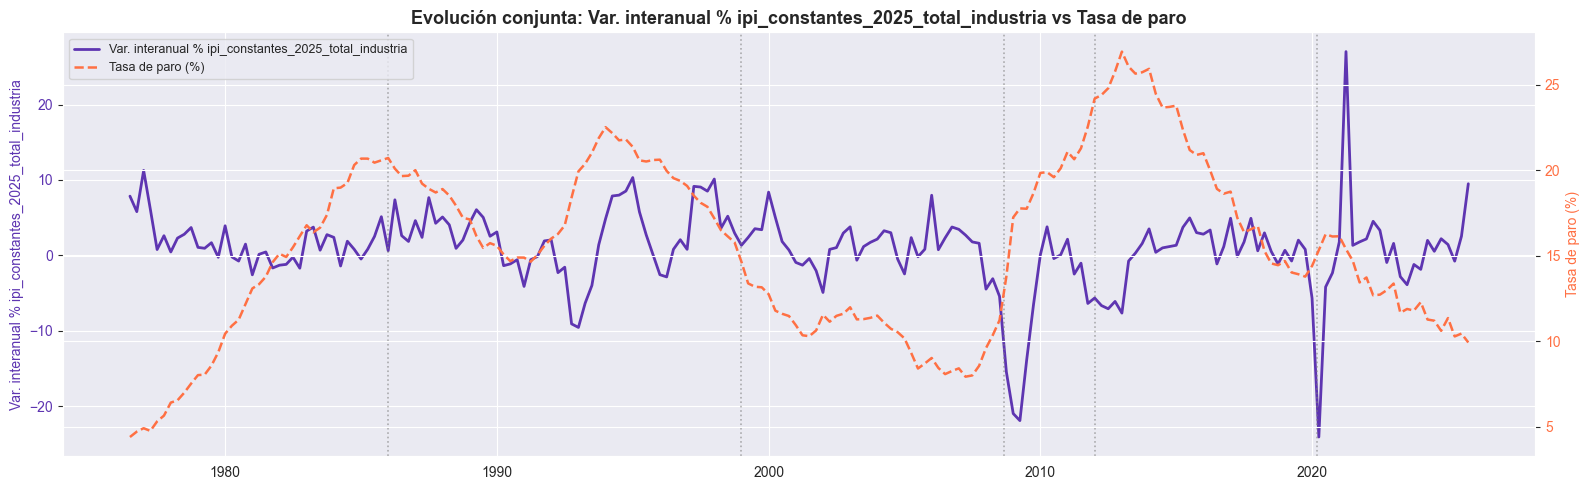

In [27]:
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.plot(main_s9.index, main_s9, color=COLOR_PRINCIPAL, lw=2,
         label=main_s9_label)
ax2.plot(parados_aligned.index, parados_aligned, color='#FF7043',
         lw=1.8, linestyle='--', label='Tasa de paro (%)')

ax1.set_ylabel(main_s9_label, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')

for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if main_s9.index.min() <= fecha_ev <= main_s9.index.max():
        ax1.axvline(fecha_ev, color='gray', linestyle=':', lw=1.2, alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_title(f'Evolución conjunta: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis:

La evolución conjunta de la variación interanual del `ipi_constantes_2025_total_industria` y la tasa de paro muestra una relación de signo inverso en los episodios de crisis pero inestable en el conjunto de la muestra. El crecimiento de la producción industrial oscila en torno a su media próxima a cero, con los desplomes más profundos en la crisis financiera de 2008-2009 (hasta aproximadamente -30%) y en el confinamiento de 2020, los dos momentos en que la actividad industrial se contrae con mayor violencia. Esos dos valles coinciden exactamente con las dos mayores escaladas del desempleo de la muestra, la expresión más directa de la transmisión del ciclo industrial al mercado laboral.

Fuera de esos episodios extremos, sin embargo, la relación es menos nítida: en las fases expansivas el crecimiento de la producción y el descenso del paro no siempre se sincronizan con la misma intensidad, y hay tramos en que ambas variables se mueven en el mismo sentido. El análisis cuantitativo siguiente confirma una correlación global débil que esconde una relación fuerte y negativa concentrada en los periodos de crisis industrial.

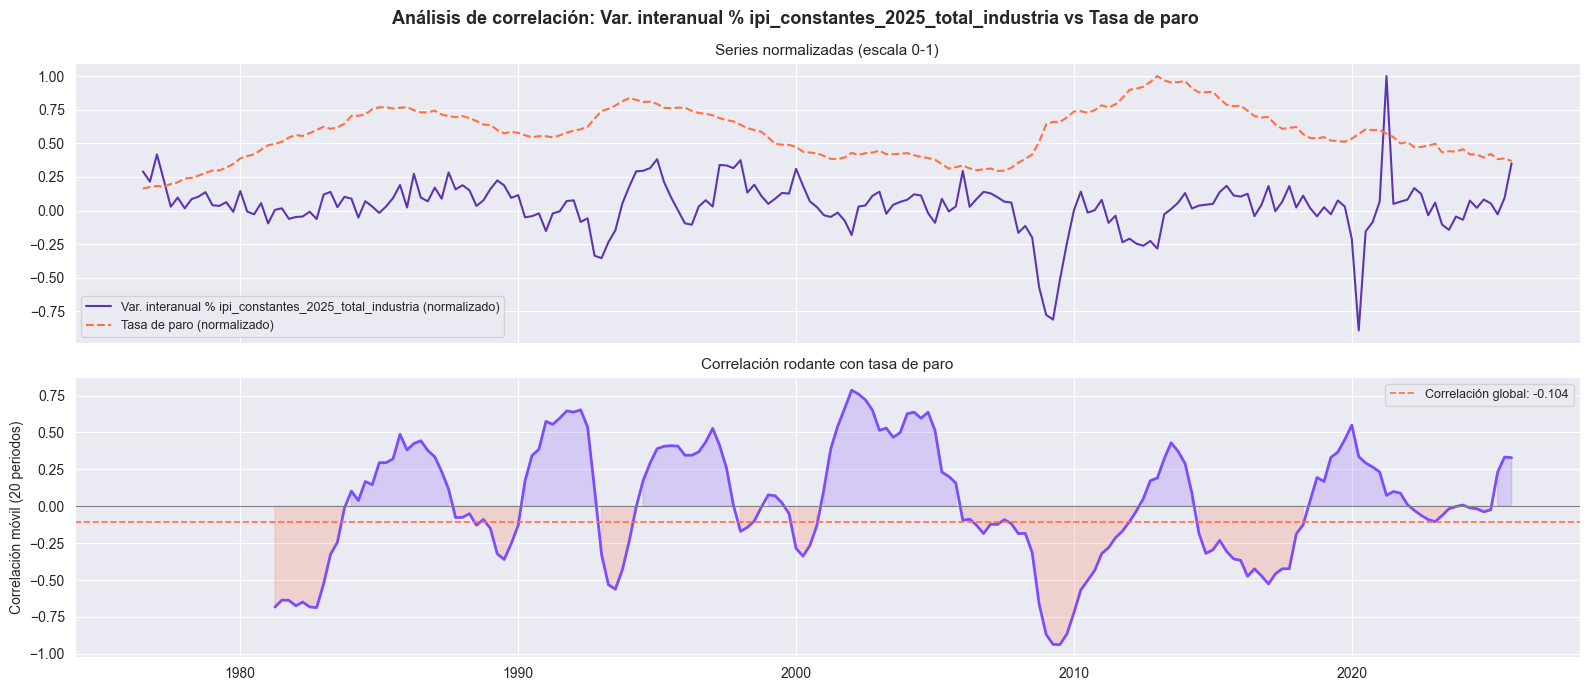

Correlación de Pearson global: -0.1044


In [28]:
ventana_corr = 20

df_cross = pd.DataFrame({'ipi': main_s9, 'parados': parados_aligned}).dropna()
rolling_corr = df_cross['ipi'].rolling(ventana_corr).corr(df_cross['parados'])
corr_global = df_cross['ipi'].corr(df_cross['parados'])

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df_cross.index, df_cross['ipi'] / df_cross['ipi'].max(),
             color=COLOR_PRINCIPAL, lw=1.5, label=f'{main_s9_label} (normalizado)')
axes[0].plot(df_cross.index, df_cross['parados'] / df_cross['parados'].max(),
             color='#FF7043', lw=1.5, linestyle='--', label='Tasa de paro (normalizado)')
axes[0].legend(fontsize=9)
axes[0].set_title('Series normalizadas (escala 0-1)', fontsize=11)

axes[1].plot(rolling_corr.index, rolling_corr, color='#7C4DFF', lw=2)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axhline(corr_global, color='#FF7043', lw=1.2, linestyle='--',
                label=f'Correlación global: {corr_global:.3f}')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr > 0, alpha=0.2, color='#7C4DFF')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr < 0, alpha=0.2, color='#FF7043')
axes[1].set_ylabel(f'Correlación móvil ({ventana_corr} periodos)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_title('Correlación rodante con tasa de paro', fontsize=11)

fig.suptitle(f'Análisis de correlación: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Correlación de Pearson global: {corr_global:.4f}')

### Análisis:

La correlación global entre la variación interanual del `ipi_constantes_2025_total_industria` y la tasa de paro es de -0,1044, débil en el agregado pero, como en el PIB, resultado de promediar regímenes de signo opuesto. La correlación rodante a 20 trimestres oscila con gran amplitud entre aproximadamente +0,8 y -0,95, alternando tramos en que la producción industrial y el paro se mueven en sentido inverso con tramos en que lo hacen en el mismo sentido.

El tramo más informativo y de mayor magnitud es el de la crisis financiera: entre 2008 y 2010 la correlación rodante alcanza su mínimo, en torno a -0,95, el valor más extremo de toda la serie, cuando el colapso de la producción industrial coincide con la mayor escalada del desempleo. Otros tramos negativos aparecen en 1981-1983 y 2015-2018. Los tramos positivos (1985-1992, 2001-2006) corresponden a periodos en que la producción crece de forma sostenida mientras el paro evoluciona por sus propios factores estructurales, sin acoplarse a la dinámica industrial. La correlación global de -0,1044 subestima por tanto el poder predictivo del IPI, que es fuerte y negativo en las recesiones industriales, el momento en que más importa para anticipar el desempleo.

Para la caracterización de la variable, el crecimiento de la producción industrial es un indicador relevante del ciclo cuya relación con el paro se intensifica en las crisis; su aprovechamiento, condicionado al régimen, se difiere a la fase de feature engineering.

In [29]:
df_cross['decada'] = (df_cross.index.year // 10 * 10).astype(str) + 's'
paleta_decadas = ['#1565C0', '#00897B', '#FF7043', '#7C4DFF', '#FFC107', '#AD1457']

df_scatter = df_cross.reset_index().rename(columns={'index': 'fecha', df_cross.index.name or 'index': 'fecha'})
if 'fecha' not in df_scatter.columns:
    df_scatter.insert(0, 'fecha', df_cross.index.strftime('%Y-%m-%d'))
else:
    df_scatter['fecha'] = pd.to_datetime(df_scatter['fecha']).dt.strftime('%Y-%m-%d')

fig = px.scatter(
    df_scatter, x='ipi', y='parados',
    color='decada',
    hover_data=['fecha'],
    trendline='ols',
    trendline_scope='overall',
    color_discrete_sequence=paleta_decadas,
    title=f'Dispersión por década: {main_s9_label} vs Desempleo',
    labels={
        'ipi': main_s9_label,
        'parados': 'Tasa de paro (%)',
        'decada': 'Década', 'fecha': 'Fecha',
    },
)
fig.for_each_trace(lambda t: t.update(name='Tendencia global') if t.name == 'Overall Trendline' else None)
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.update_layout(height=520)
fig.show()

### Análisis:

El diagrama de dispersión por década confirma una relación inversa débil entre el crecimiento de la producción industrial y el paro, con una recta de tendencia global de pendiente ligeramente negativa, desde aproximadamente 18% de paro en el extremo de variación -25% hasta cerca del 13% en el extremo +30%, coherente con la correlación global de -0,10.

La nube es muy dispersa y la estratificación por década es menos limpia que en el PIB, lo que refleja que la relación es ruidosa y dominada por otros factores fuera de los episodios de crisis. Los años 2000 (morados) tienden a situarse en la zona de paro bajo, los 2010 (amarillos) en la de paro alto, y la mayor parte de las observaciones se concentra en torno a una variación interanual pequeña (entre -5% y +5%) con un rango de paro muy amplio, lo que confirma que para un crecimiento industrial moderado el nivel de paro depende sobre todo del régimen macroeconómico. Los puntos extremos de la cola izquierda, con variación interanual muy negativa, corresponden a las recesiones industriales y se asocian a niveles de paro elevados, anclando la pendiente negativa.

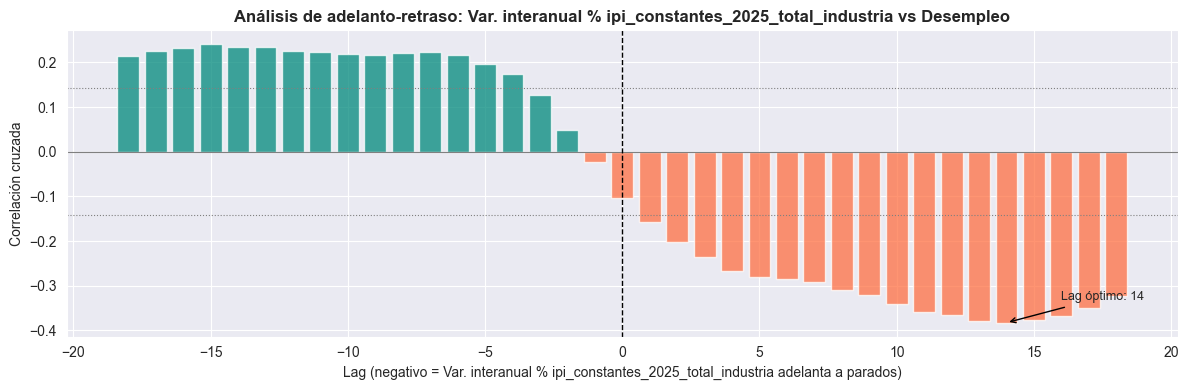

Lag con máxima correlación: 14 periodos
Correlación en ese lag: -0.3828
Banda de significancia (±2/√N): ±0.1421


In [30]:
max_lag = LAGS_ACF // 2

sa = (df_cross['ipi'] - df_cross['ipi'].mean()) / df_cross['ipi'].std()
sb = (df_cross['parados'] - df_cross['parados'].mean()) / df_cross['parados'].std()

lags_range = range(-max_lag, max_lag + 1)
ccf_vals = [sa.corr(sb.shift(-lag)) for lag in lags_range]

fig, ax = plt.subplots(figsize=(12, 4))
colors_ccf = ['#00897B' if v > 0 else '#FF7043' for v in ccf_vals]
ax.bar(list(lags_range), ccf_vals, color=colors_ccf, alpha=0.75)
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='black', lw=1, linestyle='--')
sig = 2 / np.sqrt(len(df_cross))
ax.axhline(sig, color='gray', lw=0.8, linestyle=':')
ax.axhline(-sig, color='gray', lw=0.8, linestyle=':')

lag_max = list(lags_range)[np.argmax(np.abs(ccf_vals))]
ax.annotate(f'Lag óptimo: {lag_max}', xy=(lag_max, ccf_vals[lag_max + max_lag]),
            xytext=(lag_max + 2, ccf_vals[lag_max + max_lag] + 0.05),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel(f'Lag (negativo = {main_s9_label} adelanta a parados)', fontsize=10)
ax.set_ylabel('Correlación cruzada', fontsize=10)
ax.set_title(f'Análisis de adelanto-retraso: {main_s9_label} vs Desempleo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Lag con máxima correlación: {lag_max} periodos')
print(f'Correlación en ese lag: {ccf_vals[lag_max + max_lag]:.4f}')
print(f'Banda de significancia (±2/√N): ±{sig:.4f}')

### Análisis:

El análisis de adelanto-retraso presenta un perfil asimétrico. En los lags negativos, donde la variación de la producción adelanta al paro, las correlaciones son positivas y estables en torno a +0,20 a +0,24, lo que resulta anómalo respecto a la transmisión esperada (mayor producción debería anticipar menos paro, con signo negativo) y refleja, como en el PIB, la contaminación de los tramos en que el crecimiento industrial y el paro coincidieron al alza. En los lags positivos, donde el paro adelanta a la producción, las correlaciones son negativas y crecientes en valor absoluto hasta el lag óptimo de +14 trimestres, con una correlación de -0,3828 que supera con holgura la banda de significancia de ±0,1421.

Un lag óptimo positivo de catorce trimestres, alrededor de tres años y medio, con correlación negativa, indica que los episodios de alto desempleo se asocian a una menor producción industrial varios años después, una relación de reversión y persistencia de largo plazo más que de transmisión adelantada. Los lags operativos de corto plazo, del contemporáneo al -4, muestran correlaciones débiles, próximas a cero o ligeramente positivas, lo que confirma que la variación de la producción industrial no aporta señal predictiva apreciable sobre el paro en horizontes cortos de forma aislada. Su valor, fuerte en las recesiones, es condicional al régimen y su explotación se difiere a la fase de feature engineering.